# Práctica 05: Un viaje visual y revelador - DonorsChoose

**Programa de estudios:** Ingeniería en Entornos Vistuales Y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Período:** Mayo - Agosto 2026 

### Unidad 2: Preparación de los Datos

**Nombre del estudiante:** Karla Yulenni Domínguez Amador \
**Matrícula:** 230284 \
**Grado y Grupo:** 9°A IEVND

![](https://i.imgur.com/X6bTc7G.png)

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%);
padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
Un viaje visual y revelador - DonorsChoose
</h1>

<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
Ciencia de datos para el bien social DonorsChoose es una organización sin fines de lucro con sede en Estados Unidos que permite a particulares donar directamente a proyectos para aulas de escuelas públicas. Para enero de 2018, DonorsChoose.org había financiado un millón de proyectos; de hecho, el 77 % de las escuelas públicas de Estados Unidos ha solicitado al menos un proyecto a través de esta plataforma. DonorsChoose ha compartido un conjunto de datos completo que incluye todos los proyectos anteriores y los recursos asociados, así como metadatos sobre docentes, escuelas, donantes y donaciones. Estos datos permiten extraer información valiosa y desarrollar una solución que posibilite a DonorsChoose.org crear campañas de correo electrónico dirigidas, recomendando solicitudes específicas de aulas a donantes anteriores. En este *notebook*, he realizado un análisis y una exploración exhaustivos del conjunto de datos compartido. Este documento no solo aporta información clave derivada de los datos de DonorsChoose, sino que también sirve como tutorial para llevar a cabo análisis de datos (incluido el análisis exploratorio) y visualizaciones de datos.
    
</p>

</div>

### 📋 Tabla de contenidos

---

| # | Sección | Descripción |
|---|---|---|
| 1 | [Preparación del conjunto de datos](#s1) |Importeción de las bibliotecas  |


## 1. Preparación del conjunto de datos. <a id='s1'></a>

<div style="background: #fff8e1;  padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Importemos las bibliotecas necesarias y carguemos el conjunto de datos.</b><br>
</div>

In [90]:
!pip install wordcloud
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go
import matplotlib.pyplot as plt
from plotly import tools
from datetime import date
import pandas as pd
import numpy as np
import seaborn as sns
import random
import warnings
import operator
from wordcloud import WordCloud
!pip install folium
warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

path = "datasets/"
donors_df = pd.read_csv(path+"Donors.csv/Donors.csv")
donations_df = pd.read_csv(path+"Donations.csv/Donations.csv")
teachers_df = pd.read_csv(path+"Teachers.csv")

## 2. Exploración de los donantes. <a id='s2'></a>

<div style="background: #fff8e1;  padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>El conjunto de datos de donantes contiene información sobre cada persona que ha realizado al menos una donación en DonorsChoose, incluyendo datos como su ciudad, estado, código postal y si son docentes.</b><br>
</div>

## 2.1 Vista general de los donantes <a id='s2.1'></a>

In [91]:
###### total rows
# donors_df.shape

###### total cities 
# len(donors_df['Donor City'].value_counts())

# more than one donation
# t = donations_df['Donor ID'].value_counts().to_frame()
# len(t[t['Donor ID']>1])

donors_df.head(3)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,00000ce845c00cbf0686c992fc369df4,Evanston,Illinois,No,602
1,00002783bc5d108510f3f9666c8b1edd,Appomattox,other,No,245
2,00002d44003ed46b066607c5455a999a,Winton,California,Yes,953



Existen un total de **2,122,640 donantes** registrados en DonorsChoose hasta abril de 2018. Estos donantes pertenecen a **15,204 ciudades diferentes** de Estados Unidos y algunos otros países. De ese número tan grande de donantes, solo **552,941 (aproximadamente 26%)** han donado más de una vez. Uno de los principales objetivos del reto Data Science for Good es encontrar patrones e insights relevantes que permitan generar recomendaciones, de modo que se pueda inspirar a los donantes a volver a donar. Hay alrededor de **1,471,613 donantes** que han hecho solo 1 donación, por lo que DonorsChoose tiene la oportunidad de motivar a estas personas a realizar otro pago.

## 2.2 Donantes de cada estado <a id='s2.2'></a>

## 2.2.1 Número de donantes por estado <a id='s2.2.1'></a>

In [92]:
import folium
from folium import plugins
from io import StringIO
import folium 


statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = states_df = donors_df['Donor State'].value_counts()
t1 = pd.DataFrame()
t1['Donor State'] = tempdf.index
t1['Donor Count'] = tempdf.values

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')
sdf 

# --- CORRECCIÓN DEL RADIO ---
# El multiplicador fijo (0.0001) estaba pensado para el dataset completo de Kaggle,
# donde los conteos de donantes por estado llegan a cientos de miles.
# En nuestra muestra (Donors.csv) los conteos son mucho más pequeños (decenas),
# así que ese multiplicador daba radios casi invisibles (menores a 1 pixel).
# En vez de un número fijo, normalizamos el radio entre un mínimo y un máximo
# usando el propio rango de nuestros datos (escalado min-max), así el mapa
# se ve bien sin importar el tamaño del dataset.
radio_min, radio_max = 8, 45  # rango de radios visibles en pixeles, ajústalo a tu gusto
conteo_min = sdf['Donor Count'].min()
conteo_max = sdf['Donor Count'].max()

def escalar_radio(conteo):
    if conteo_max == conteo_min:
        return (radio_min + radio_max) / 2
    return radio_min + (conteo - conteo_min) / (conteo_max - conteo_min) * (radio_max - radio_min)

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker(
        [float(rown[1]), float(rown[2])],
        popup="<b>State:</b>" + rown[0].title() + "<br> <b>Donors:</b> " + str(int(rown[3])),
        radius=escalar_radio(float(rown[3])),
        color='#be0eef',
        fill=True,
        fill_color='#be0eef',
        fill_opacity=0.7
    ).add_to(map4)
map4

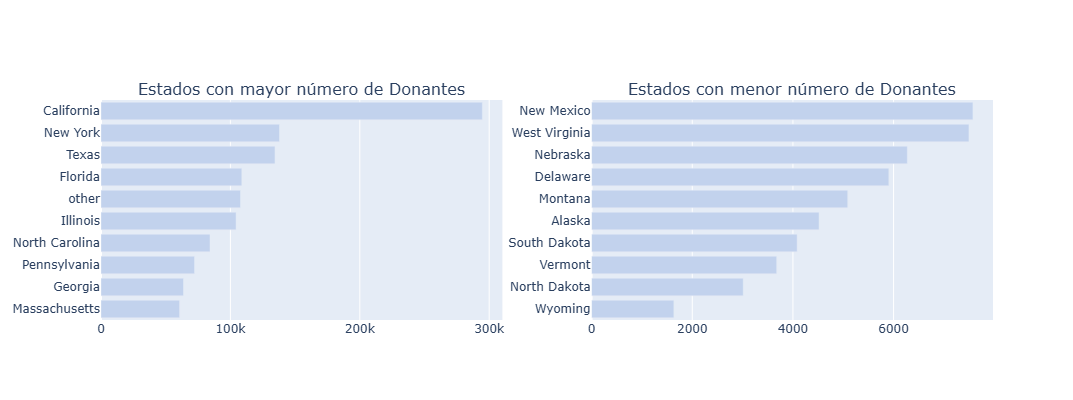

In [93]:
def bar_hor(df, col, title, color, w=None, h=None, lm=0, limit=100, return_trace=False, rev=False):
    # Contamos cuántas veces aparece cada valor único en la columna indicada
    cnt_srs = df[col].value_counts()
    # Tomamos los "limit" valores más altos (orden ascendente para graficar de abajo hacia arriba)
    yy = cnt_srs.head(limit).index[::-1] 
    xx = cnt_srs.head(limit).values[::-1] 
    if rev:
        # Si "rev" es True, tomamos los valores más bajos en lugar de los más altos
        yy = cnt_srs.tail(limit).index[::-1] 
        xx = cnt_srs.tail(limit).values[::-1] 
        
    # Creamos la barra horizontal
    trace = go.Bar(y=yy, x=xx, orientation = 'h', marker=dict(color=color))
    if return_trace:
        return trace 
    # Configuramos el diseño de la gráfica (título, márgenes, ancho, alto)
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

def bar_hor_noagg(x, y, title, color, w=None, h=None, lm=0, limit=100, rt=False):
    # Igual que la función anterior, pero sin hacer conteo (los datos ya vienen agregados)
    trace = go.Bar(y=x, x=y, orientation = 'h', marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


def bar_ver_noagg(x, y, title, color, w=None, h=None, lm=0, rt = False):
    # Misma lógica pero para una gráfica de barras verticales
    trace = go.Bar(y=y, x=x, marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

    
# Generamos las gráficas de las ciudades y estados con más donantes
trace1 = bar_hor(donors_df, 'Donor City', "Ciudades con mayor número de Donantes", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace2 = bar_hor(donors_df, 'Donor State', "Estados con mayor número de Donantes", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
# rev=True indica que se tomen los estados con MENOS donantes
trace4 = bar_hor(donors_df, 'Donor State', "Estados con menor número de Donantes", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True, rev=True)

# Creamos una figura con 1 fila y 2 columnas para comparar ambas gráficas lado a lado
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Estados con mayor número de Donantes','Estados con menor número de Donantes'])
# fig = tools.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], print_grid=False, subplot_titles = ['Estados con mayor número de Donantes','Estados con menor número de Donantes', 'Ciudades con mayor número de Donantes'])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
# fig.append_trace(trace1, 2, 1);

fig['layout'].update(height=400, showlegend=False);
iplot(fig);

- California, al ser el estado con mayor población, también tiene una base de donantes registrados muy grande, con cerca de 300,000 donantes. **San Francisco y Los Ángeles** son las principales ciudades de California donde se ubica la mayor parte de los donantes. El mayor número de escuelas y proyectos también proviene del estado de California.
- Nueva York, Texas y Florida, con aproximadamente 137,000, 134,000 y 108,000 donantes respectivamente, son los otros tres estados principales con una alta población de donantes. Las ciudades principales incluyen Nueva York, Miami, Tampa, Houston y Dallas, donde se ubica la mayoría de los donantes.
- Dakota del Norte, Dakota del Sur, Vermont y Wyoming son los estados con un número muy bajo de donantes, menos de 4,000. Existe un registro llamado "otros" en los datos de estados, que probablemente indica donantes que son maestros o donantes de otros países.
- Entre las ciudades de EE.UU. en general, las tres principales son: **Chicago (aprox. 35K donantes), Nueva York (aprox. 27K donantes) y Brooklyn (aprox. 22K donantes)**, con el mayor número de donantes. Las ciudades californianas SF y LA son las siguientes dos ciudades con una gran base de donantes, con aprox. 18K y aprox. 16K donantes.

## Dataset Ajustado por Población

Los estados principales en las gráficas anteriores son en realidad los estados con mayor población. Sería interesante averiguar el número de donantes por cada 100,000 habitantes para cada estado. Por ello, he agregado un dataset de población que incluye la población de cada estado a partir de 2013.

Dataset de Población: http://www.enchantedlearning.com/usa/states/population.shtml

## 2.3 Estados con la mayor **proporción de donantes por habitante** <a id='s2.3'></a>

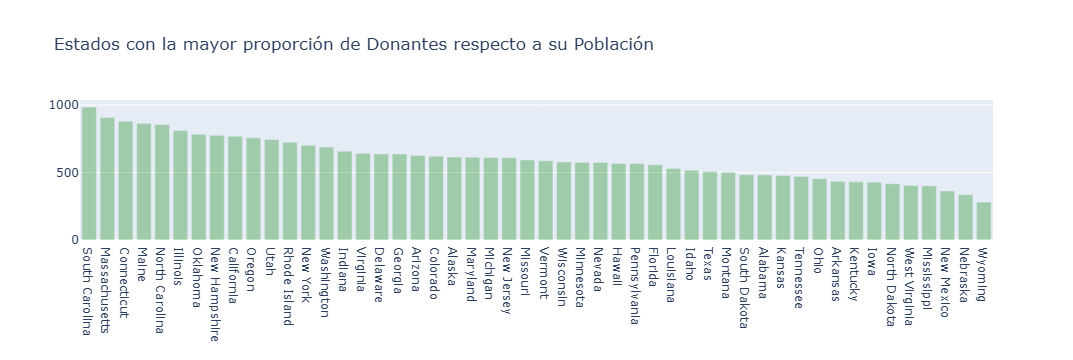

In [94]:
# Población de cada estado según el censo de 2013
census_2013 = {'Mississippi': 2991207, 'Iowa': 3090416, 'Oklahoma': 3850568, 'Delaware': 925749, 'Minnesota': 5420380, 'Alaska': 735132, 'Illinois': 12882135, 'Arkansas': 2959373, 'New Mexico': 2085287, 'Indiana': 6570902, 'Maryland': 5928814, 'Louisiana': 4625470, 'Texas': 26448193, 'Wyoming': 582658, 'Arizona': 6626624, 'Wisconsin': 5742713, 'Michigan': 9895622, 'Kansas': 2893957, 'Utah': 2900872, 'Virginia': 8260405, 'Oregon': 3930065, 'Connecticut': 3596080, 'New York': 19651127, 'California': 38332521, 'Massachusetts': 6692824, 'West Virginia': 1854304, 'South Carolina': 4774839, 'New Hampshire': 1323459, 'Vermont': 626630, 'Georgia': 9992167, 'North Dakota': 723393, 'Pennsylvania': 12773801, 'Florida': 19552860, 'Hawaii': 1404054, 'Kentucky': 4395295, 'Rhode Island': 1051511, 'Nebraska': 1868516, 'Missouri': 6044171, 'Ohio': 11570808, 'Alabama': 4833722, 'South Dakota': 844877, 'Colorado': 5268367, 'Idaho': 1612136, 'New Jersey': 8899339, 'Washington': 6971406, 'North Carolina': 9848060, 'Tennessee': 6495978, 'Montana': 1015165, 'District of Columbia': 646449, 'Nevada': 2790136, 'Maine': 1328302}

# Contamos cuántos donantes hay por cada estado
donors_from_states = dict(donors_df['Donor State'].value_counts())

# Calculamos la proporción de donantes por cada 100,000 habitantes
don_pop = {}
for state, don in donors_from_states.items():
    if state not in census_2013:
        # Si el estado no está en el censo (por ejemplo "other"), lo ignoramos
        continue
    don_pop[state]  = float(don)*100000/ census_2013[state]

import operator
# Ordenamos los estados de mayor a menor según su proporción de donantes
don_pop = sorted(don_pop.items(), key=operator.itemgetter(1), reverse = True)
# Excluimos el primer elemento (posible valor atípico) y separamos nombres y valores
xx = [x[0] for x in (don_pop)][1:]
yy = [x[1] for x in (don_pop)][1:]

# Creamos la gráfica de barras
trace2 = go.Bar(
    x=xx,
    y=yy,
    name='Donantes respecto a la Población',
    marker=dict(color='green'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'Estados con la mayor proporción de Donantes respecto a su Población',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

- Se genera una gráfica interesante en la que los estados **Carolina del Sur** (con población = 4,774,839), **Massachusetts** (con población = 6,692,824) y **Connecticut** (con población = 3,596,080) tienen la mayor proporción de donantes respecto a su población, así como el mayor número de donantes por cada 100,000 habitantes. Carolina del Sur = 985 donantes por cada 100K habitantes, Massachusetts = 907 donantes por cada 100K habitantes, y Connecticut = 878 donantes por cada 100K habitantes.
- Wyoming, Nebraska y Nuevo México tienen el menor número de donantes por cada 100K habitantes, con 285, 335 y 363 donantes respectivamente.
- Texas, uno de los estados con mayor número de donantes en total, tiene una proporción de donantes respecto a su población más baja, equivalente a 508 donantes por cada 100K habitantes.

## 2.4 Visualicemos dónde se encuentran los donantes <a id='s2.4'></a>

## 2.4.1 Ubicación de los donantes en California <a id='s2.4.1'></a>

In [95]:
# Datos de ciudades de California: nombre, latitud, longitud, total de donantes, color y tamaño del punto
calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")

# Cargamos los datos en un DataFrame y eliminamos filas vacías
cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)


# Creamos un mapa centrado en California, con estilo oscuro
map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')

# Armamos un arreglo con [latitud, longitud, número de donantes] para cada ciudad
ziparr = []
for i, row in cities.iterrows():
    # Quitamos las comas del número (ej. "17,922" -> "17922") y lo convertimos a float
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])

# Agregamos un mapa de calor (heatmap) al mapa, donde las zonas con más donantes se ven más intensas
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2  # Mostramos el mapa

### Las ubicaciones clave donde la densidad de donantes es mayor son las siguientes:

```text
- Los Angeles, 17,922
- San Francisco, 16,553
- San Diego, 9,072
- San Jose, 7,674
- Oakland, 6,783
```

## 2.4.2 Donde se encuentran los donantes en Florida <a id='s2.4.2'></a>

In [96]:
import random

# Cargar el archivo de ciudades con coordenadas
c = pd.read_csv(path + "zip_codes_states.csv")

# Filtrar únicamente las ciudades del estado de Florida
fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

# Normalizar nombres de ciudades
fldf['city'] = fldf['city'].str.upper().str.strip()

# Obtener una única latitud y longitud por ciudad
fldf = fldf.groupby('city').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# Contar donantes por ciudad
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City']
t = t.str.upper().str.strip().value_counts()
fldons = pd.DataFrame({
    'city': t.index,
    'count': t.values
})

# Unir ciudades con coordenadas
florida = fldons.merge(fldf, on='city', how='left').dropna()

# Crear el mapa
map_osm2 = folium.Map(
    [29.813456, -82.472049],
    zoom_start=6.2,
    tiles='cartodbdark_matter'
)

# Generar más puntos para que el mapa de calor sea más parecido al original
ziparr = []
for _, row in florida.iterrows():
    n = max(5, int(row['count'] / 5))
    for _ in range(n):
        lat = row['latitude'] + random.uniform(-0.15, 0.15)
        lon = row['longitude'] + random.uniform(-0.15, 0.15)
        ziparr.append([lat, lon, row['count'] * 3])

# Crear el mapa de calor
plugins.HeatMap(
    ziparr,
    radius=18,
    blur=18,
    min_opacity=0.35,
    max_zoom=8
).add_to(map_osm2)

map_osm2

### Análisis de la distribución de donantes en Florida

La región del sur de Florida, conformada por **Palm Beach, Miami-Dade y Broward**, presenta la mayor concentración de donantes. Además, la ciudad de **Tampa** registra un número importante de donantes. También se observa una presencia significativa de donantes en **Key West**, ubicada en el extremo sur del estado de Florida.

Las cinco ciudades con mayor número de donantes son:

- **Miami:** 9,309 donantes
- **Tampa:** 6,016 donantes
- **Orlando:** 5,658 donantes
- **Jacksonville:** 4,598 donantes
- **Fort Lauderdale:** 4,311 donantes

In [97]:
fldf = c[c['state'] == 'NY'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'New York']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([42.315975, -74.065515], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=13))


### Análisis de donantes en Nueva York

Los donantes del estado de Nueva York provienen principalmente de **New York City**. 

Las cinco ciudades con mayor número de donantes son:

- **New York:** 26,820 donantes  
- **Brooklyn:** 21,715 donantes  
- **Staten Island:** 4,516 donantes  
- **Bronx:** 4,455 donantes  
- **Buffalo:** 2,232 donantes  

## 2.4.4 Ubicación de los donantes en Texas  <a id='s2.4.4'></a>

In [98]:
fldf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([31.884540, -97.077218], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

### Análisis de donantes en Texas

Las principales ciudades de Texas donde se encuentran los donantes son:

- **Houston:** 15,404 donantes  
- **Austin:** 9,958 donantes  
- **Dallas:** 7,818 donantes  
- **San Antonio:** 6,465 donantes  
- **Fort Worth:** 4,350 donantes  

## 2.5 ¿Dónde se encuentran los donantes? <a id='s2.5'></a>

In [99]:
fldf = c[['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([39.3714557,-94.3541242], zoom_start=3.5,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=10))

### Análisis de la distribución de donantes en Estados Unidos

Aunque el mayor número de donantes proviene del estado de **California**, ubicado en la costa oeste, la región de la **costa este de Estados Unidos presenta una mayor densidad de donantes en comparación con la costa oeste**.

Además, se observa una cantidad significativa de donantes en los estados de **Hawái** y **Alaska**, lo que indica una distribución geográfica más amplia a nivel nacional.

## 2.6 Número de docentes y donantes no docentes de cada estado <a id='s2.6'></a>

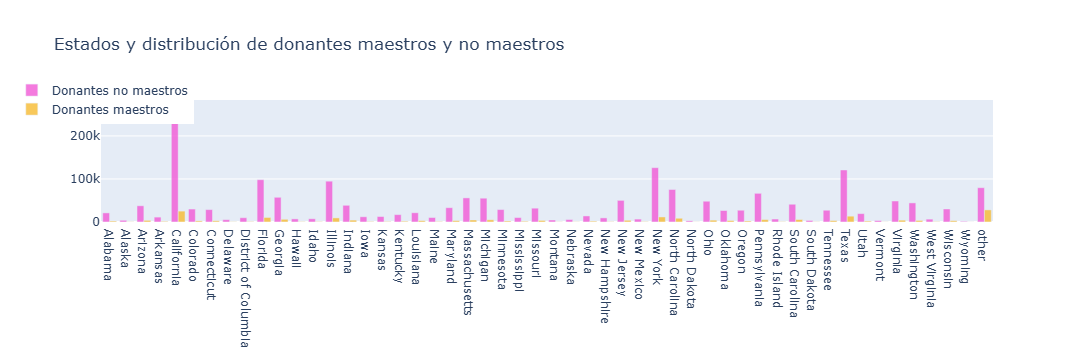

In [100]:
# ¿En qué estado hay más donantes que son maestros?

tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({
    'Donor Is Teacher': 'count'
}).rename(columns={'Donor Is Teacher': 'Teacher Donor Counts'}).reset_index()

# Filtrar donantes que NO son maestros
no_df = tempdf[tempdf['Donor Is Teacher'] == 'No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']

# Filtrar donantes que SÍ son maestros
yes_df = tempdf[tempdf['Donor Is Teacher'] == 'Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

# Gráfico de barras para donantes NO maestros
trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Donantes no maestros',
    marker=dict(color='#f259d6'),
    opacity=0.8
)

# Gráfico de barras para donantes maestros
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Donantes maestros',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

# Combinar datos
data = [trace1, trace2]

# Diseño del gráfico
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title='Estados y distribución de donantes maestros y no maestros'
)

# Crear figura
fig = go.Figure(data=data, layout=layout)

# Mostrar gráfico
iplot(fig, filename='grouped-bar')

### Análisis de donantes maestros por estado

El número de donantes que son maestros es generalmente bajo en todos los estados. Sin embargo, el registro correspondiente al estado **"Others"** presenta el mayor número de donantes maestros, con aproximadamente **28,000** casos.

## 3. Exploración de las donaciones <a id='s3'></a>



El archivo de donaciones contiene información sobre las donaciones realizadas por los donantes, incluyendo el monto total de cada donación, la secuencia del carrito del donante, la fecha, el proyecto y el ID del donante.

## 3.1 Instantáneas de las donaciones <a id='s3.1'></a>

In [101]:
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].rename(columns={
    'Donation ID': 'ID de Donación',
    'Donation Included Optional Donation': 'Incluye Donación Opcional',
    'Donation Amount': 'Monto de Donación',
    'Donor Cart Sequence': 'Secuencia de Carrito del Donante',
    'Donation Received Date': 'Fecha de Recepción',
    'Project ID': 'ID de Proyecto',
    'Donor ID': 'ID de Donante'
}).head(3)

# len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] < 1])
# np.mean(donations_df['Donation Amount'])

,ID de Donación,Incluye Donación Opcional,Monto de Donación,Secuencia de Carrito del Donante,Fecha de Recepción,ID de Proyecto,ID de Donante
0,688729120858666221208529ee3fc18e,No,178.37,11,2016-08-23 13:15:57,000009891526c0ade7180f8423792063,1f4b5b6e68445c6c4a0509b3aca93f38
1,dcf1071da3aa3561f91ac689d1f73dee,Yes,25.00,2,2016-06-06 20:05:23,000009891526c0ade7180f8423792063,4aaab6d244bf3599682239ed5591af8a
2,18a234b9d1e538c431761d521ea7799d,Yes,20.00,3,2016-06-06 14:08:46,000009891526c0ade7180f8423792063,0b0765dc9c759adc48a07688ba25e94e


### Exploración de las donaciones

Se muestran las primeras 3 filas del conjunto de datos de donaciones, seleccionando columnas relevantes como el ID de la donación, si incluye una donación opcional, el monto de la donación, la secuencia del carrito del donante, la fecha de recepción, el ID del proyecto y el ID del donante.

```python
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].head(3)

# Exploración adicional del dataset:
# donations_df.columns

# Tamaño del dataset
# len(donations_df)

# Proporción de donaciones mayores a 20000
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)

# Proporción de donaciones mayores a 10000
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)

# Donaciones menores a 1 dólar
# len(donations_df[donations_df['Donation Amount'] < 1])

# Promedio del monto de donación
# np.mean(donations_df['Donation Amount'])
```

### Análisis general de las donaciones

Hasta abril de 2018, en DonorsChoose se han realizado un total de **4,687,884 donaciones**. El monto más alto donado es de **USD 60,000**, registrado en el año 2013.

Solo **6 donaciones** superan los **USD 20,000**, mientras que únicamente **61 pagos** son mayores a **USD 10,000**. La mayoría de los pagos (aproximadamente **83% del total**) son menores a **USD 100**.

Además, existen **350 pagos menores a USD 1**, los cuales, aunque pequeños, pueden hacer una diferencia. En total, la plataforma DonorsChoose ha recaudado aproximadamente **USD 284,408,243**. El monto promedio de donación es de aproximadamente **USD 60**.

En las siguientes secciones se analizarán los detalles de los donantes y los proyectos relacionados con estas donaciones.

## 3.2 Proyectos y sus donaciones <a id='s3.2'></a>

### Identificación de los principales proyectos y sus atributos

En esta sección se identifican los proyectos más destacados en función de diferentes métricas relacionadas con las donaciones:

#### 3.2.1 Proyectos con mayor número de donantes  
#### 3.2.2 Proyectos con mayor monto total financiado  
#### 3.2.3 Proyectos con mayor monto promedio por donante  
#### 3.2.4 Proyectos con la mayor donación individual registrada  

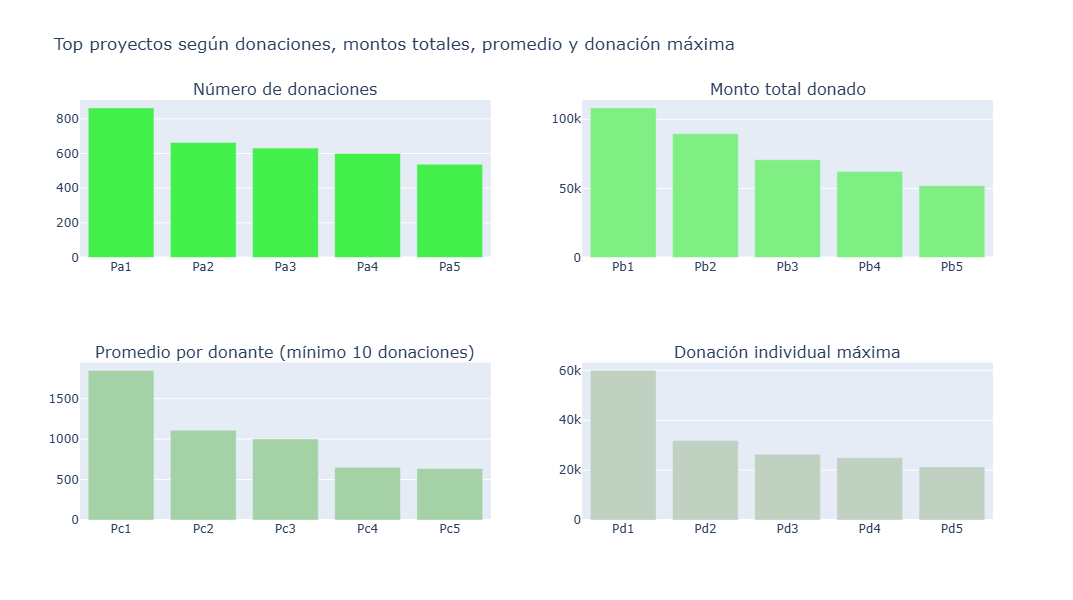

In [102]:
# ¿Qué proyectos tienen el mayor número de donaciones?

# Agrupar por Project ID para obtener:
# - número total de donaciones
# - suma total de dinero donado
tempdf = donations_df.groupby('Project ID').agg({
    'Project ID': 'count',
    'Donation Amount': 'sum'
}).rename(columns={
    'Project ID': "Total Donations",
    'Donation Amount': "Total Amount"
}).reset_index()

# Calcular el promedio de donación por proyecto
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']


# -----------------------------
# 1. Proyectos con más donaciones
# -----------------------------
tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])

x = tempdf1.head(5)['Project ID']
x = ["Pa" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']

tr1 = bar_ver_noagg(x, y, 'Total Donations', '#43ef4b', lm=None, rt=True)


# -----------------------------
# 2. Proyectos con mayor monto total
# -----------------------------
tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])

x = tempdf1.head(5)['Project ID']
x = ["Pb" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']

tr2 = bar_ver_noagg(x, y, 'Monto Total Donado', '#7fef84', lm=None, rt=True)


# -----------------------------
# 3. Proyectos con mayor promedio por donación
# (mínimo 10 donaciones)
# -----------------------------
tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])

x = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Project ID']
x = ["Pc" + str(i+1) for i in range(len(x))]
y = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Average Donation Amount']

tr3 = bar_ver_noagg(x, y, 'Promedio por donante (mínimo 10 donaciones)', '#a5d1a7', lm=None, rt=True)


# -----------------------------
# 4. Proyectos con mayor donación individual
# -----------------------------
tempdf = donations_df.groupby('Project ID').agg({
    'Project ID': 'count',
    'Donation Amount': 'max'
}).rename(columns={
    'Project ID': "Total Donations",
    'Donation Amount': "Maximum Donation"
}).reset_index()

tempdf1 = tempdf.sort_values(by=['Maximum Donation'], ascending=[False])

x = tempdf1.head(5)['Project ID']
x = ["Pd" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donation']

tr4 = bar_ver_noagg(x, y, 'Donación individual máxima', '#c0d1c1', lm=None, rt=True)


# -----------------------------
# Gráfico final combinado
# -----------------------------
fig = tools.make_subplots(
    rows=2, cols=2,
    print_grid=False,
    subplot_titles=[
        'Número de donaciones',
        "Monto total donado",
        'Promedio por donante (mínimo 10 donaciones)',
        'Donación individual máxima'
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 2)
fig.append_trace(tr3, 2, 1)
fig.append_trace(tr4, 2, 2)

fig['layout'].update(
    height=600,
    showlegend=False,
    title='Top proyectos según donaciones, montos totales, promedio y donación máxima'
)

iplot(fig)

### Proyectos destacados

A lo largo de la historia de DonorsChoose, diferentes proyectos han recibido un número variable de donaciones, desde tan solo 1 hasta más de 800 donaciones. El número máximo de donaciones en un solo proyecto es de **863**. Este proyecto fue liderado por un maestro y su título fue *"Vallecito StandUpKids Pilot Standing School!"* (mostrado como **Pa1** en el primer gráfico). En este proyecto se recaudó un total de **USD 108,248.30**, y fue completamente financiado el **26 de agosto de 2015**.

Además, existen otros tres proyectos con un número muy alto de donaciones (mayor a 600).

En noviembre de 2016, el proyecto titulado *"Varsity and After-School Fencing Teams in NYC"* (mostrado como **Pc1** en el segundo gráfico) fue iniciado y recibió 18 donaciones en total. Este proyecto presentó el mayor promedio por donante, con un valor de **USD 1,850**.

Por otro lado, en el proyecto *"Learning to Play While Playing to Learn!"* (mostrado como **Pd1** en el cuarto gráfico), se registró la donación individual más alta de la historia de DonorsChoose, con un monto de **USD 60,000**.

## 3.3 ¿Quiénes son los principales donantes?: <a id='s3.3'></a>

### Identificación de los principales donantes y sus contribuciones

En esta sección se identifican los donantes más destacados según diferentes métricas relacionadas con sus contribuciones:

#### 3.3.1 Donantes con mayor número de donaciones  
#### 3.3.2 Donantes que han aportado el mayor monto total  
#### 3.3.3 Donantes con mayor monto promedio por donación  
#### 3.3.4 Donantes con la mayor donación individual registrada  

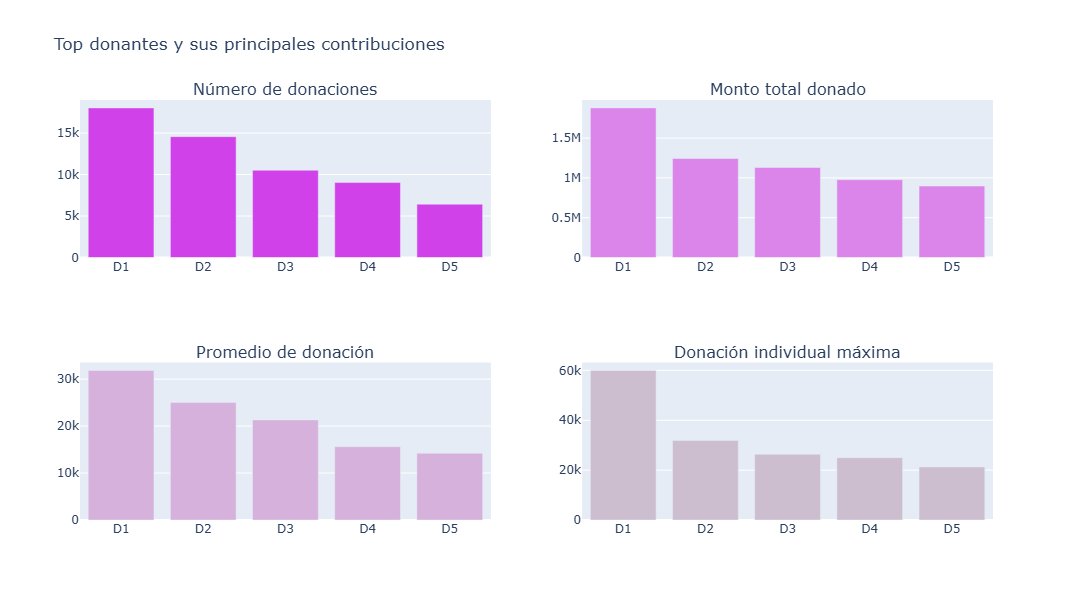

In [103]:
# ¿Qué donantes han hecho las mayores contribuciones?

# Agrupar por Donor ID para obtener:
# - número total de donaciones
# - suma total donada
tempdf = donations_df.groupby('Donor ID').agg({
    'Donor ID': 'count',
    'Donation Amount': 'sum'
}).rename(columns={
    'Donor ID': "Total Donations",
    'Donation Amount': "Total Amount"
}).reset_index()

# Calcular el promedio de donación por donante
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']


# -----------------------------
# 1. Donantes con más donaciones
# -----------------------------
tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])

x = tempdf1.head(5)['Donor ID']
x = ["D" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']

tr1 = bar_ver_noagg(x, y, 'Número total de donaciones', '#d141ea', lm=None, rt=True)


# -----------------------------
# 2. Donantes con mayor monto total
# -----------------------------
tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])

x = tempdf1.head(5)['Donor ID']
x = ["D" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']

tr2 = bar_ver_noagg(x, y, 'Monto total donado', '#db85ea', lm=None, rt=True)


# -----------------------------
# 3. Donantes con mayor promedio por donación
# -----------------------------
tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])

x = tempdf1.head(5)['Donor ID']
x = ["D" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Average Donation Amount']

tr3 = bar_ver_noagg(x, y, 'Promedio por donación', '#d5b1db', lm=None, rt=True)


# -----------------------------
# 4. Donantes con mayor donación individual
# -----------------------------
tempdf = donations_df.groupby('Donor ID').agg({
    'Donor ID': 'count',
    'Donation Amount': 'max'
}).rename(columns={
    'Donor ID': "Total Donations",
    'Donation Amount': "Maximum Donation"
}).reset_index()

tempdf1 = tempdf.sort_values(by=['Maximum Donation'], ascending=[False])

x = tempdf1.head(5)['Donor ID']
x = ["D" + str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donation']

tr4 = bar_ver_noagg(x, y, 'Donación individual máxima', '#ccbece', lm=None, rt=True)


# -----------------------------
# Gráfico final combinado
# -----------------------------
fig = tools.make_subplots(
    rows=2, cols=2,
    print_grid=False,
    subplot_titles=[
        'Número de donaciones',
        "Monto total donado",
        'Promedio de donación',
        'Donación individual máxima'
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 2)
fig.append_trace(tr3, 2, 1)
fig.append_trace(tr4, 2, 2)

fig['layout'].update(
    height=600,
    showlegend=False,
    title='Top donantes y sus principales contribuciones'
)

iplot(fig)

* **Donantes Más Generosos:**
* Un donante que no es maestro de **Manhattan Beach, California** ha donado más de **18,000 veces** (mostrado como D1 en la gráfica superior izquierda) en donorschoose. Otro donante que no es maestro de Nueva York ha donado una cantidad total masiva equivalente a **1.8 M USD** en aproximadamente 10,513 donaciones (mostrado como D1 en la gráfica superior derecha).
* El pago único más alto fue de **60K** para el proyecto "Learning to Play while Playing to Learn", realizado por un donante de Anahola, Hawaii, quien ha hecho un total de 223 donaciones hasta ahora.

## 3.4 ¿Qué cantidades de donación se recibieron y en qué momentos? <a id='s3.4'></a>

**Donaciones anuales:**
* 3.4.1 Número de donaciones por año
* 3.4.2 Importe promedio de las donaciones por año

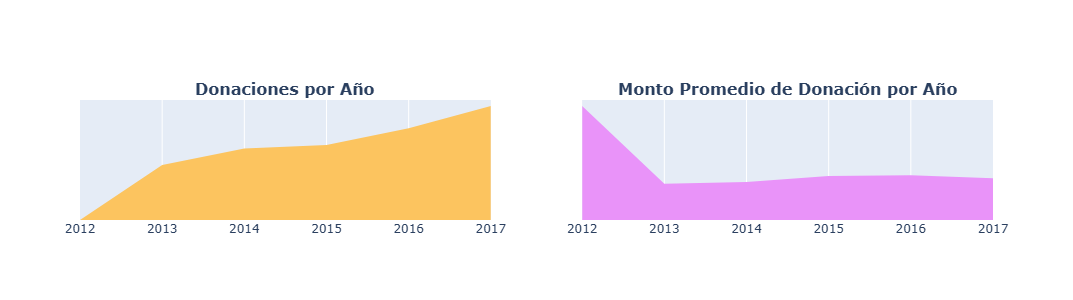

In [104]:
# Convertir la columna de fecha de recepción a formato de fecha (datetime)
donations_df['Donation Date'] = pd.to_datetime(donations_df['Donation Received Date'])

# Extraer el año de la donación
donations_df['Donation Year'] = donations_df['Donation Date'].dt.year

# Extraer el mes de la donación
donations_df['Donation Month'] = donations_df['Donation Date'].dt.month

# Extraer el día de la donación
donations_df['Donation Day'] = donations_df['Donation Date'].dt.day

# Extraer el día de la semana de la donación (0 = lunes, 6 = domingo)
donations_df['Donation Weekday'] = donations_df['Donation Date'].dt.weekday

# Extraer la hora de la donación
donations_df['Donation Hour'] = donations_df['Donation Date'].dt.hour

# Agrupar por año: contar total de donaciones y calcular el monto promedio
t1 = donations_df.groupby(['Donation Year']).agg({
    'Donation Month': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Month': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

# Definir los ejes x e y para las gráficas
x = t1['Donation Year']
y1 = t1['Total Donations']
y2 = t1['Average Amount']

# Crear la primera gráfica: Donaciones totales por año
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor='#fcc45f', mode='none')

# Crear la segunda gráfica: Monto promedio de donación por año
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor="#e993f9", mode='none')

# Crear la figura con 2 subgráficas (una fila, dos columnas)
fig = tools.make_subplots(
    rows=1, cols=2, print_grid=False,
    subplot_titles=["<b>Donaciones por Año</b>", "<b>Monto Promedio de Donación por Año</b>"]
)

# Agregar cada gráfica a su posición correspondiente
fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

# Configurar el diseño general de la figura (ocultar ejes y leyenda)
fig['layout'].update(
    height=300, showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

# Mostrar la figura
iplot(fig)

Desde el año 2012, el número de donaciones en donorschoose ha ido incrementando de manera regular. Con aproximadamente 150 donaciones recibidas en 2012, donorschoose recibió cerca de **1.1 Millones de donaciones** en el año 2017. El monto más alto recibido en 2017 fue de **USD 31,856**, el cual fue recibido de un donante de **Lafayette, Colorado**. Esta donación fue recibida el 02 de marzo de 2017.

En ese mismo año, se recibió un número gigantesco de donaciones de un donante de **Manhattan Beach, California**, quien realizó 13,751 donaciones.

El monto promedio de donación recibido por año es cercano a **USD 60**, mientras que fue más alto en el año inicial, es decir, en 2012, equivalente a **USD 166**.

**Donaciones mensuales:**
* 3.4.3 Número de donaciones mensuales
* 3.4.4 Promedio de donaciones mensuales

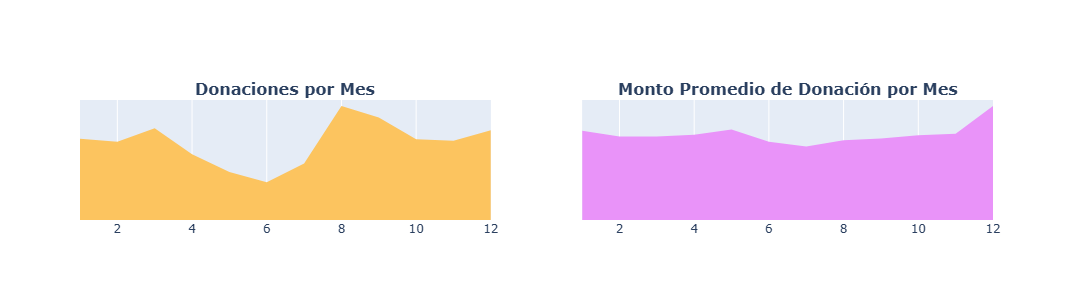

In [105]:
# Agrupar por mes: contar total de donaciones y calcular el monto promedio
t2 = donations_df.groupby(['Donation Month']).agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

# Definir los ejes x e y para las gráficas
x = t2['Donation Month']
y1 = t2['Total Donations']
y2 = t2['Average Amount']

# Crear la primera gráfica: Donaciones totales por mes
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor='#fcc45f', mode='none')

# Crear la segunda gráfica: Monto promedio de donación por mes
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor="#e993f9", mode='none')

# Crear la figura con 2 subgráficas (una fila, dos columnas)
fig = tools.make_subplots(
    rows=1, cols=2, print_grid=False,
    subplot_titles=["<b>Donaciones por Mes</b>", "<b>Monto Promedio de Donación por Mes</b>"]
)

# Agregar cada gráfica a su posición correspondiente
fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

# Configurar el diseño general de la figura (ocultar ejes y leyenda)
fig['layout'].update(
    height=300, showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

# Mostrar la figura
iplot(fig)

* El mayor número de donaciones se recibe en el mes de **Agosto** con **577,274 Donaciones**, seguido por el mes de **Septiembre** con **518,908 donaciones**, mientras que el menor número de donaciones se recibe en el mes de **Junio**, equivalente a **191,221 donaciones**, y el mes de **Mayo**, equivalente a **243,440 donaciones**, probablemente por el verano y las vacaciones. El monto promedio de donación más alto se recibe en el mes de **Diciembre** con **USD 80**, mientras que el más bajo es en el mes de **Julio**, equivalente a **USD 51**. En promedio, el monto promedio de donación por año es cercano a USD 59.

**Donaciones por Mes y Día**
* 3.4.5 Número de Donaciones por Mes y Día
* 3.4.6 Monto Promedio de Donaciones por Mes y Día

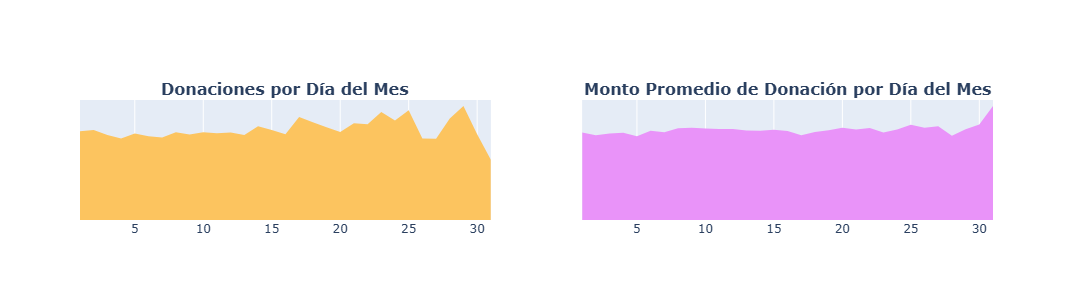

In [106]:
# Agrupar por día del mes: contar total de donaciones y calcular el monto promedio
t3 = donations_df.groupby(['Donation Day']).agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

# Definir los ejes x e y para las gráficas
x = t3['Donation Day']
y1 = t3['Total Donations']
y2 = t3['Average Amount']

# Crear la primera gráfica: Donaciones totales por día del mes
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor='#fcc45f', mode='none')

# Crear la segunda gráfica: Monto promedio de donación por día del mes
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor="#e993f9", mode='none')

# Crear la figura con 2 subgráficas (una fila, dos columnas)
fig = tools.make_subplots(
    rows=1, cols=2, print_grid=False,
    subplot_titles=["<b>Donaciones por Día del Mes</b>", "<b>Monto Promedio de Donación por Día del Mes</b>"]
)

# Agregar cada gráfica a su posición correspondiente
fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

# Configurar el diseño general de la figura (ocultar ejes y leyenda)
fig['layout'].update(
    height=300, showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

# Mostrar la figura
iplot(fig)

**Donaciones por día de la semana**
* 3.4.7 Número de donaciones por día de la semana
* 3.4.8 Promedio de donaciones por día de la semana

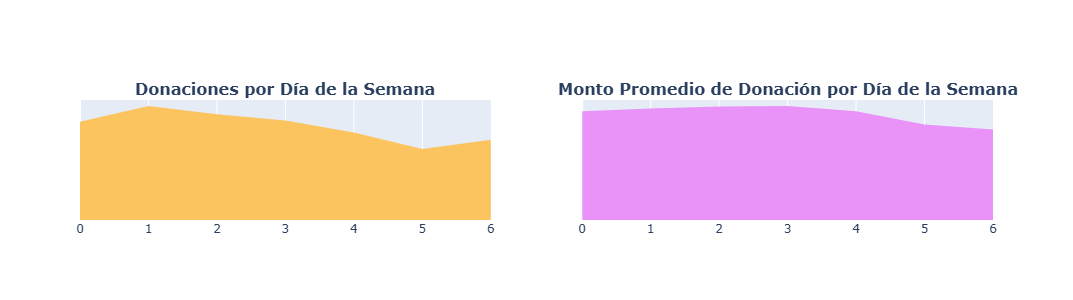

In [107]:
# Agrupar por día de la semana: contar total de donaciones y calcular el monto promedio
t4 = donations_df.groupby(['Donation Weekday']).agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

# Definir los ejes x e y para las gráficas
x = t4['Donation Weekday']
y1 = t4['Total Donations']
y2 = t4['Average Amount']

# Crear la primera gráfica: Donaciones totales por día de la semana
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor='#fcc45f', mode='none')

# Crear la segunda gráfica: Monto promedio de donación por día de la semana
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor="#e993f9", mode='none')

# Crear la figura con 2 subgráficas (una fila, dos columnas)
fig = tools.make_subplots(
    rows=1, cols=2, print_grid=False,
    subplot_titles=["<b>Donaciones por Día de la Semana</b>", "<b>Monto Promedio de Donación por Día de la Semana</b>"]
)

# Agregar cada gráfica a su posición correspondiente
fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

# Configurar el diseño general de la figura (ocultar ejes y leyenda)
fig['layout'].update(
    height=300, showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

# Mostrar la figura
iplot(fig)

> El número de donaciones es más alto en los primeros días de la semana, es decir, lunes, martes y miércoles, con 700K, 800K y 750K donaciones totales respectivamente, y el conteo disminuye conforme avanzan los días de la semana. El menor número de donaciones se recibe los sábados, como se observa en la gráfica.

**Donaciones por Hora**
* 3.4.9 Número de Donaciones por Hora
* 3.4.10 Monto Promedio de Donaciones por Hora

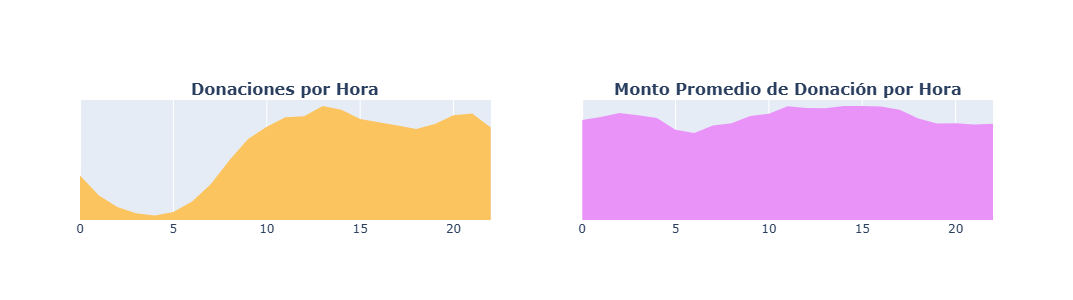

In [108]:
# Agrupar por hora: contar total de donaciones y calcular el monto promedio
t5 = donations_df.groupby(['Donation Hour']).agg({
    'Donation Month': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Month': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

# Definir los ejes x e y para las gráficas
x = t5['Donation Hour']
y1 = t5['Total Donations']
y2 = t5['Average Amount']

# Crear la primera gráfica: Donaciones totales por hora
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor='#fcc45f', mode='none')

# Crear la segunda gráfica: Monto promedio de donación por hora
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor="#e993f9", mode='none')

# Crear la figura con 2 subgráficas (una fila, dos columnas)
fig = tools.make_subplots(
    rows=1, cols=2, print_grid=False,
    subplot_titles=["<b>Donaciones por Hora</b>", "<b>Monto Promedio de Donación por Hora</b>"]
)

# Agregar cada gráfica a su posición correspondiente
fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

# Configurar el diseño general de la figura (ocultar ejes y leyenda)
fig['layout'].update(
    height=300, showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

# Mostrar la figura
iplot(fig)

## 3.5 Donaciones opcionales y donantes de maestros <a id='s3.5'></a>

#### 3.5.1 Total de donaciones opcionales y sus importes medios asociados

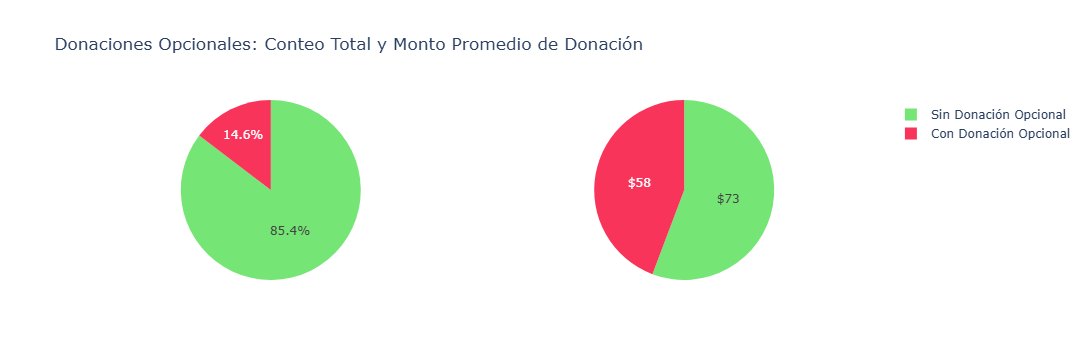

In [109]:
# Agrupar por si la donación incluyó donación opcional: contar total y calcular monto promedio
tempdf = donations_df.groupby('Donation Included Optional Donation').agg({
    'Donation Included Optional Donation': 'count',
    'Donation Amount': 'mean'
})

# Obtener los valores de conteo y de monto promedio
values1 = list(tempdf['Donation Included Optional Donation'])
values2 = list(tempdf['Donation Amount'])
values2t = [str("$") + str(int(x)) for x in values2]

domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

# Traducir las etiquetas (Sí/No) a texto descriptivo en español
labels = list(tempdf.index)
mp = {'Yes': 'Con Donación Opcional', 'No': 'Sin Donación Opcional'}
labels = [mp[x] for x in labels]

# Crear las gráficas de pastel individuales (no usadas directamente, se arma la figura combinada abajo)
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=['#75e575', '#ea7c96']))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96']), textinfo="text", text=values2t)

layout = go.Layout(title='Número de Donaciones con Donación Opcional', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Monto Promedio Donado en Donaciones Opcionales', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

# Crear la figura final con las dos gráficas de pastel (dona) lado a lado
fig = {
  "data": [
    {
      "values": values1,
      "labels": list(reversed(labels)),
      "domain": {"x": [0, .48]},
      "marker": dict(colors=['#f9345b', '#75e575']),
      "name": "No. de donaciones con Donación Opcional",
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
      "marker": dict(colors=['75e575', '#f9345b']),
      "domain": {"x": [.52, 1]},
      "name": "Monto Promedio Donado en Donaciones Opcionales",
      "text": values2t,
      "textinfo": "text",
      "type": "pie"
    }],
  "layout": {
        "title": "Donaciones Opcionales: Conteo Total y Monto Promedio de Donación",
    }
}

# Mostrar la figura
iplot(fig, filename='donut')

>Los proyectos de DonorsChoose también ofrecen la opción de realizar donaciones opcionales. El importe medio de una donación opcional es de **58 USD**, frente a los **73** USD de las donaciones no opcionales. Del total de donaciones realizadas, aproximadamente el **15 %** fueron opcionales.

#### 3.5.2 Total de donaciones de docentes donantes y los importes medios asociados

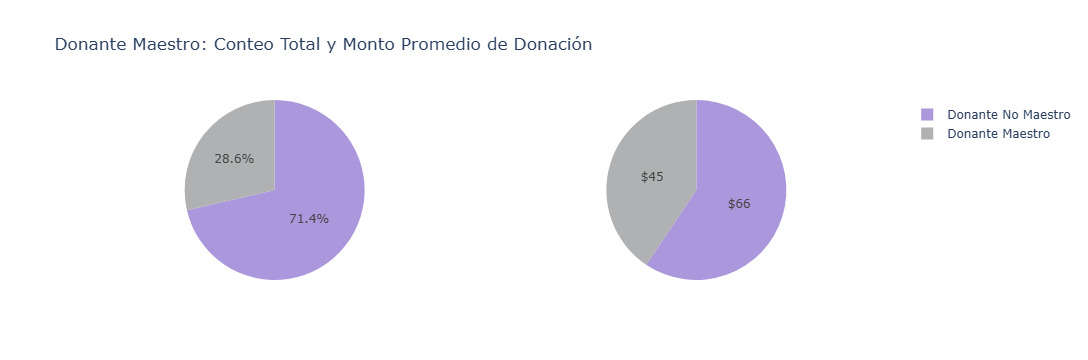

In [110]:
# Combinar donantes y donaciones
combined_df = donations_df.merge(donors_df, on='Donor ID', how='inner')
# combined_df.head(10)

# Agrupar por si el donante es maestro: contar total y calcular monto promedio
tempdf = combined_df.groupby('Donor Is Teacher').agg({
    'Donor Is Teacher': 'count',
    'Donation Amount': 'mean'
})

# Obtener los valores de conteo y de monto promedio
values1 = list(tempdf['Donor Is Teacher'])
values2 = list(tempdf['Donation Amount'])
values2t = [str("$") + str(int(x)) for x in values2]

domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

# Traducir las etiquetas (Sí/No) a texto descriptivo en español
labels = list(tempdf.index)
mp = {'Yes': 'Donante Maestro', 'No': 'Donante No Maestro'}
labels = [mp[x] for x in labels]

# Crear las gráficas de pastel individuales (no usadas directamente, se arma la figura combinada abajo)
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=['#75e575', '#ea7c96']))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96']), textinfo="text", text=values2t)

layout = go.Layout(title='Número de Donaciones según si el Donante es Maestro', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Monto Promedio Donado según si el Donante es Maestro', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

# Crear la figura final con las dos gráficas de pastel (dona) lado a lado
fig = {
  "data": [
    {
      "values": values1,
      "labels": labels,
      "domain": {"x": [0, .48]},
      "marker": dict(colors=['#ab97db', '#b0b1b2']),
      "name": "No. de donaciones según si el Donante es Maestro",
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
      "marker": dict(colors=['#ab97db', '#b0b1b2']),
      "domain": {"x": [.52, 1]},
      "name": "Monto Promedio Donado según si el Donante es Maestro",
      "text": values2t,
      "textinfo": "text",
      "type": "pie"
    }],
  "layout": {
        "title": "Donante Maestro: Conteo Total y Monto Promedio de Donación",
    }
}

# Mostrar la figura
iplot(fig, filename='donut')

>* Alrededor del 29 % del total de las donaciones en DonorsChoose provienen de donantes que también son docentes. La mayor parte de estos docentes donantes reside en California.
>* El importe promedio de las donaciones realizadas por docentes es de 45 USD, frente a los 66 USD de los donantes que no son docentes.

In [111]:
def mapp(df, scl, t):
    state_to_code = {'District of Columbia' : 'dc','Mississippi': 'MS', 'Oklahoma': 'OK', 'Delaware': 'DE', 'Minnesota': 'MN', 'Illinois': 'IL', 'Arkansas': 'AR', 'New Mexico': 'NM', 'Indiana': 'IN', 'Maryland': 'MD', 'Louisiana': 'LA', 'Idaho': 'ID', 'Wyoming': 'WY', 'Tennessee': 'TN', 'Arizona': 'AZ', 'Iowa': 'IA', 'Michigan': 'MI', 'Kansas': 'KS', 'Utah': 'UT', 'Virginia': 'VA', 'Oregon': 'OR', 'Connecticut': 'CT', 'Montana': 'MT', 'California': 'CA', 'Massachusetts': 'MA', 'West Virginia': 'WV', 'South Carolina': 'SC', 'New Hampshire': 'NH', 'Wisconsin': 'WI', 'Vermont': 'VT', 'Georgia': 'GA', 'North Dakota': 'ND', 'Pennsylvania': 'PA', 'Florida': 'FL', 'Alaska': 'AK', 'Kentucky': 'KY', 'Hawaii': 'HI', 'Nebraska': 'NE', 'Missouri': 'MO', 'Ohio': 'OH', 'Alabama': 'AL', 'Rhode Island': 'RI', 'South Dakota': 'SD', 'Colorado': 'CO', 'New Jersey': 'NJ', 'Washington': 'WA', 'North Carolina': 'NC', 'New York': 'NY', 'Texas': 'TX', 'Nevada': 'NV', 'Maine': 'ME'}
    df['state_code'] = statesdf['state'].apply(lambda x : state_to_code[x] if x in state_to_code else "")

    data = [ dict(
            type='choropleth',
            colorscale = scl,
            autocolorscale = False,
            locations = df['state_code'],
            z = df['counts'],
            locationmode = 'USA-states',
            text = df['state'],
            marker = dict(
                line = dict (
                    color = 'rgb(255,255,255)',
                    width = 2
                ) ),
            colorbar = dict(
                title = "Donors")
            ) ]

    layout = dict(
            title = t,
            geo = dict(
                scope='usa',
                projection=dict( type='albers usa' ),
                showlakes = True,
                lakecolor = 'rgb(255, 255, 255)'),
                 )

    fig = dict( data=data, layout=layout )
    iplot( fig, filename='d3-cloropleth-map' )

## 3.6 ¿Qué estados recibieron las mayores cantidades en donaciones individuales?: <a id='s3.6'></a>

* 3.6.1 Estados con los mayores importes de donación
* 3.6.2 Ciudades con los mayores importes de donación

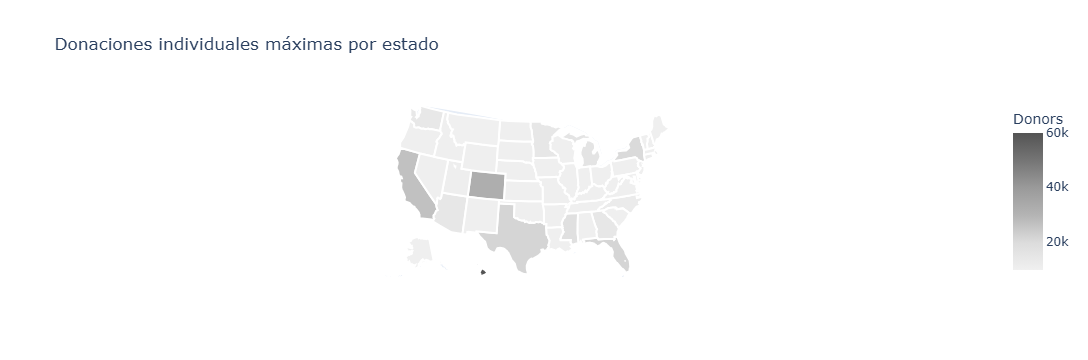

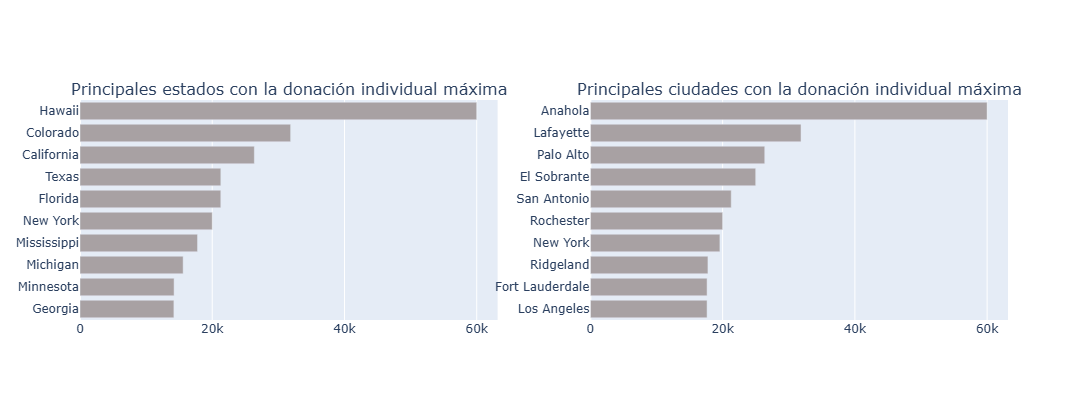

In [112]:
# Cantidades máximas de donaciones
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'max'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'max'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf


scl = [[0.0, 'rgb(240,240,240)'],
       [0.2, 'rgb(220,220,220)'],
       [0.4, 'rgb(180,180,180)'],
       [0.6, 'rgb(154,154,154)'],
       [0.8, 'rgb(117,117,117)'],
       [1.0, 'rgb(84,84,84)']]

mapp(statesdf, scl, 'Donaciones individuales máximas por estado')

trace1 = bar_hor_noagg(
    list(reversed(list(statesdf['state'][:10]))),
    list(reversed(list(statesdf['counts'][:10]))),
    "Principales ciudades con las donaciones máximas",
    '#a8a1a3',
    600, 400, 200,
    limit=10,
    rt=True
)

trace2 = bar_hor_noagg(
    list(reversed(list(citydf['state'][:10]))),
    list(reversed(list(citydf['counts'][:10]))),
    "Principales estados con las donaciones máximas",
    '#a8a1a3',
    600, 400, 200,
    limit=10,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        'Principales estados con la donación individual máxima',
        'Principales ciudades con la donación individual máxima'
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)
fig['layout'].update(height=400, showlegend=False)

iplot(fig)

> * Hawái y Colorado son los estados con menor número de donaciones, pero de ellos provienen los mayores importes donados.
> * Las ciudades de Anahola, Lafayette y Palo Alto han contribuido con las cantidades más elevadas: 60.000, 31.000 y 26.000.

## 3.7 Qué estado recibe los montos promedio de donación más altos <a id='s3.7'></a>

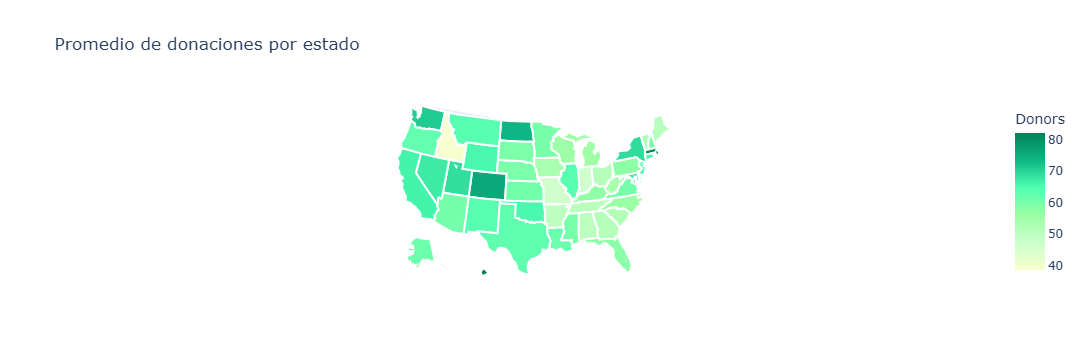

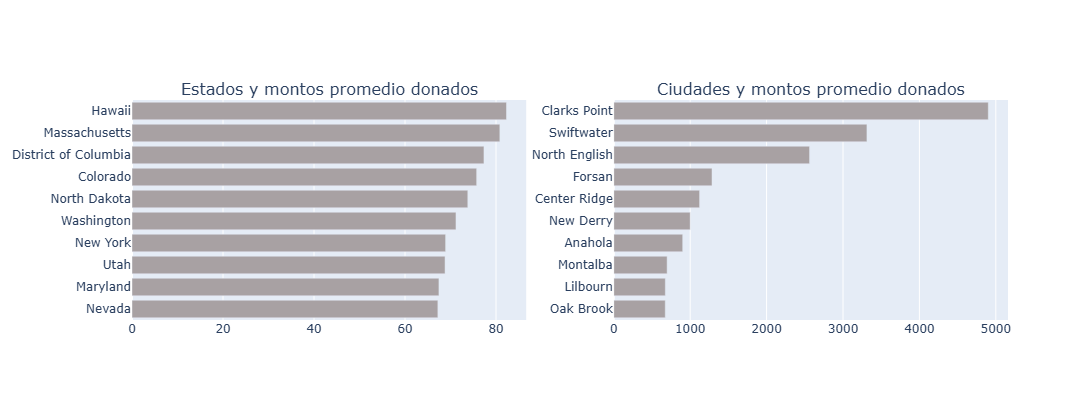

In [113]:
# Cantidades promedio de donaciones
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'mean'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'mean'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf

scl = [[0.0, 'rgb(248,255,206)'],
       [0.2, 'rgb(203,255,205)'],
       [0.4, 'rgb(155,255,164)'],
       [0.6, 'rgb(79,255,178)'],
       [0.8, 'rgb(15,183,132)'],
       [1, '#008059']]

# scl = [[0.0, 'rgb(240,240,240)'],
#        [0.2, 'rgb(220,220,220)'],
#        [0.4, 'rgb(180,180,180)'],
#        [0.6, 'rgb(154,154,154)'],
#        [0.8, 'rgb(117,117,117)'],
#        [1.0, 'rgb(84,84,84)']]

mapp(statesdf, scl, 'Promedio de donaciones por estado')

trace1 = bar_hor_noagg(
    list(reversed(list(statesdf['state'][:10]))),
    list(reversed(list(statesdf['counts'][:10]))),
    "Principales ciudades con mayores donaciones promedio",
    '#a8a1a3',
    600, 400, 200,
    limit=10,
    rt=True
)

trace2 = bar_hor_noagg(
    list(reversed(list(citydf['state'][:10]))),
    list(reversed(list(citydf['counts'][:10]))),
    "Principales estados con mayores donaciones promedio",
    '#a8a1a3',
    600, 400, 200,
    limit=10,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        'Estados y montos promedio donados',
        'Ciudades y montos promedio donados'
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)
fig['layout'].update(height=400, showlegend=False)

iplot(fig)

> * Hawái y Massachusetts tienen los montos promedio de donación más altos.
> * Clarks Point, Swiftwater y North English son las ciudades de las que se reciben los montos promedio de donación más altos.

## 3.8 Cantidad total donada de cada estado <a id='s3.8'></a>

In [114]:
statesll = StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)

for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker(
        [float(rown[1]), float(rown[2])],
        popup=rown[0] + ": $" + str(int(rown[3])),
        radius=float(rown[3]) * 0.000001,
        color='blue',
        fill=True
    ).add_to(map4)

map4

## 3.9 Donaciones de California a lo largo del tiempo <a id='s3.9'></a>

Vamos a ver la tendencia de las donaciones desde California a lo largo de los años

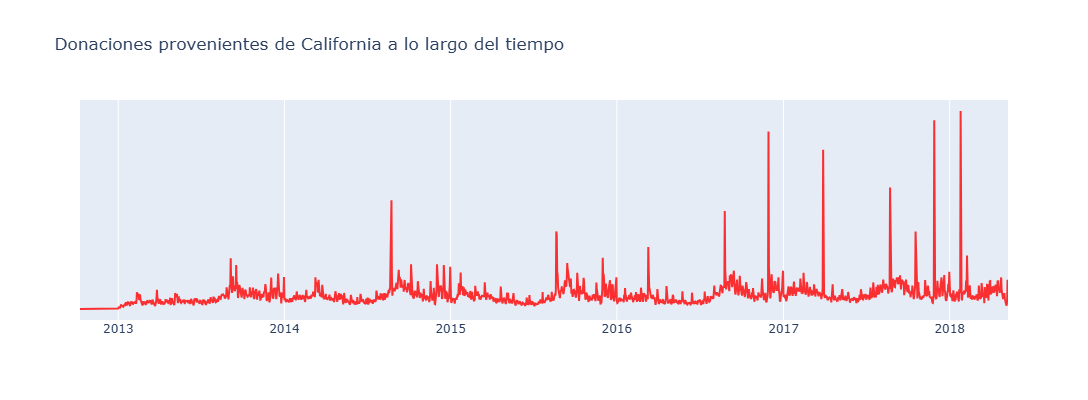

In [115]:
combined_df['Donation Date'] = combined_df['Donation Received Date'].apply(lambda x: str(x).split()[0])

cali = combined_df[combined_df['Donor State'] == 'California']
cali = cali.groupby('Donation Date').agg({'Donation Amount': 'count'}).reset_index()

cali1 = pd.DataFrame()
cali1['Date'] = pd.to_datetime(cali['Donation Date'])
cali1['Donation Amount'] = cali['Donation Amount']

trace1 = go.Scatter(
    x=cali1['Date'],
    y=cali1['Donation Amount'],
    name="California",
    line=dict(color='red'),
    opacity=0.8
)

data = [trace1]

layout = dict(
    title="Donaciones provenientes de California a lo largo del tiempo",
    height=400,
    showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

fig = dict(data=data, layout=layout)
iplot(fig)

> El número máximo de donaciones de California se dio el **25 de enero de 2018** con casi 5000 donaciones, seguido por el **28 de noviembre de 2017** con 4699 donaciones.

## 4. Exploración de los Profesores <a id='s4'></a>

## 4.1 Instantánea de los Datos de los Profesores <a id='s4.1'></a>

In [116]:
teachers_df.head(3)

# Cantidad de registros en el DataFrame de profesores
# len(teachers_df)

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date
0,bdd640fb06671ad11c80317fa3b1799d,Mrs.,2007-01-03
1,ad3c2d6d1a3d1fa7bc8960a923b8c1e9,Ms.,2014-03-26
2,0822e8f36c031199972a846916419f82,Mrs.,2006-11-27


> Hay un total de 402,900 maestros que han publicado al menos un proyecto en DonorsChoose desde 2002. La gran mayoría de los maestros son mujeres, veamos quiénes fueron los primeros maestros que publicaron proyectos en DonorsChoose.

## 4.2 Quiénes fueron los primeros maestros en DonorsChoose.org <a id='s4.2'></a>

In [117]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Teacher First Project Posted Date'])
teachers_df['Posted Year'] = teachers_df['Posted Date'].dt.year

# Vamos a descubrir quiénes fueron algunos de los primeros profesores en DonorsChoose
teachers_df[['Teacher ID', 'Posted Date']].sort_values(['Posted Date'])[:10]

,Teacher ID,Posted Date
29,6f4cc69a4b22d3081c8eaee95715bd6f,2002-01-27
78,d450281c6c6f7633a260772317a0df49,2002-01-30
114,25c73c443e75c3b4664fa6637e8f8095,2002-02-15
68,c07a30f2edd4253b50f0fd0a750cab75,2002-03-18
80,b4a69f3c8d3aed99711c21c9bdc14f1f,2002-03-21
54,ffd0f9d5a6f2f7b80cf35b5819108be5,2002-05-01
162,b63b4dc3a559e46379e13ceab0cbc61f,2002-05-22
42,3985c3cf3f76be1d1efa21977394988f,2002-06-22
87,2d534dd0cf8ebc5accc56569f9e8a369,2002-07-23
95,89456f27d7fa2d8dfb2ca025adf4e62d,2002-08-15


Los primeros maestros en DonorsChoose se registraron el 17-09-2002. Ese día se registraron 2 maestras, ambas mujeres. En el mes de septiembre de 2002, se registraron en total 8 maestros, que eran principalmente el primer grupo de maestros en DonorsChoose.

## 4..3 Crecimiento en el número de profesores a lo largo de los años <a id='s4..3'></a>

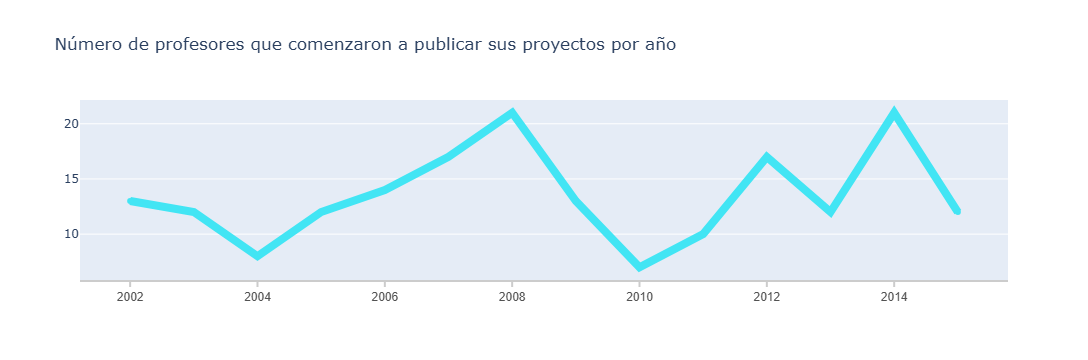

In [118]:
temp = teachers_df.groupby('Posted Year').agg({'Teacher ID': 'count'}).reset_index()
temp = temp.sort_values('Posted Year')
trace = go.Scatter(
    x=list(temp['Posted Year'])[:-1],
    y=list(temp['Teacher ID'])[:-1],
    mode='lines+markers',
    line=dict(color="#42e5f4", width=8),
    connectgaps=True,
    fillcolor='rgba(0,100,80,0.2)',
)
layout = go.Layout(
    xaxis=dict(
        showline=True,
        showgrid=False,
        showticklabels=True,
        linecolor='rgb(204, 204, 204)',
        linewidth=2,
        ticks='outside',
        tickcolor='rgb(204, 204, 204)',
        tickwidth=2,
        ticklen=5,
        tickfont=dict(
            family='Arial',
            size=12,
            color='rgb(82, 82, 82)',
        ),
    ),
    title='Número de profesores que comenzaron a publicar sus proyectos por año'
)
fig = go.Figure(data=[trace], layout=layout)
iplot(fig, filename='news-source')

> * El número de maestros que empezaron a publicar en DonorChoose cuando se lanzó en 2002 fue bajo, y los primeros cinco años hubo muy pocos maestros publicando proyectos.  
> * Una tendencia creciente comenzó a desarrollarse alrededor de 2008 y el período **2012 - 2013** vio un aumento masivo en el número de maestros publicando proyectos.  
> * La tendencia alcanzó su punto máximo con 80 mil nuevos maestros publicando proyectos en 2016, pero el número bajó a **75 mil en 2017**. No solo es necesario motivar a los donantes, sino también promover que los maestros publiquen más proyectos; al observar el crecimiento de nuevos maestros a lo largo de los años, parece que DonorChoose está haciendo un buen trabajo.  

## 4.4 ¿Cuál es la distribución de prefijos de los maestros? <a id='s4.4'></a>

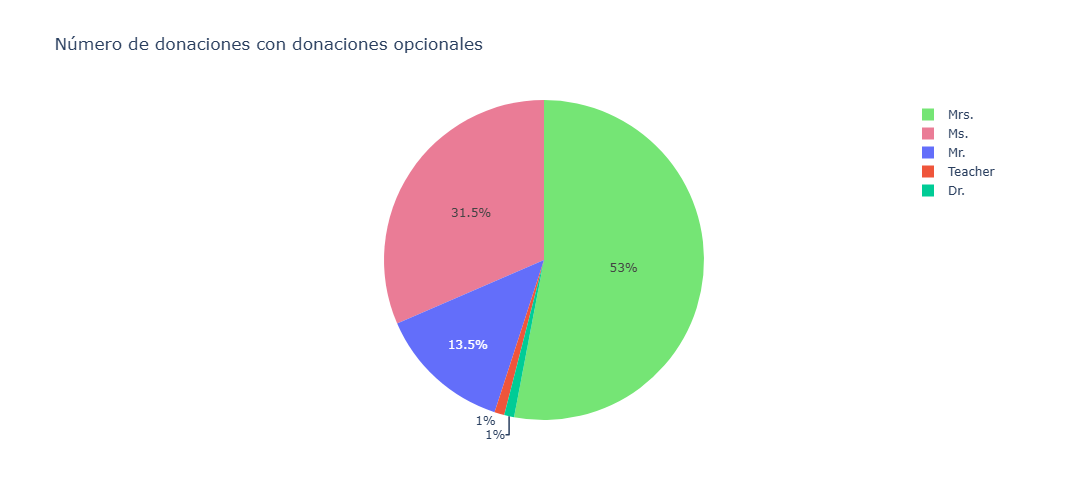

In [119]:
t = teachers_df['Teacher Prefix'].value_counts()

labels = t.index
values2 = t.values

trace2 = go.Pie(
    labels=labels,
    values=values2,
    marker=dict(colors=['#75e575', '#ea7c96'])
)

layout = go.Layout(
    title='Número de donaciones con donaciones opcionales',
    width=800,
    height=500
)

fig = go.Figure(data=[trace2], layout=layout)
iplot(fig)

## 4.5 Series temporales de los docentes publicando sus primeros proyectos <a id='s4.5'></a>

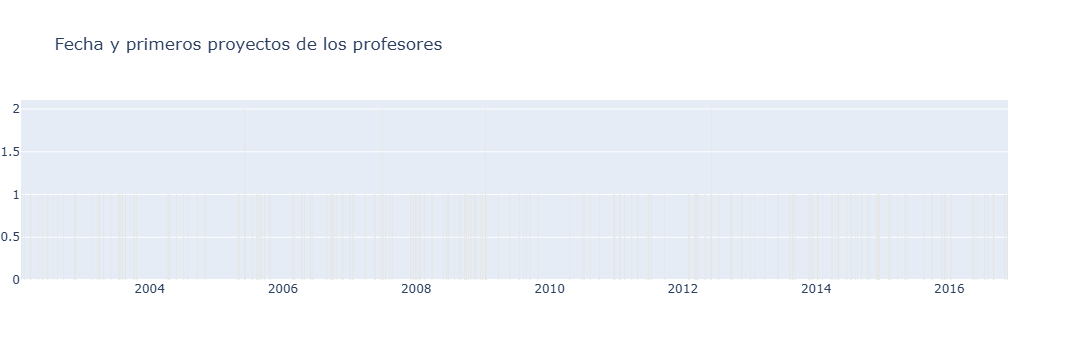

In [120]:
t = teachers_df['Posted Date'].value_counts()  # [:10]
x = t.index
y = t.values

bar_ver_noagg(x, y, 'Fecha y primeros proyectos de los profesores', 'orange')

> * El mayor número de proyectos realizados por primera vez se observó el **13 de septiembre de 2015, con un total de 2067 proyectos**. 
> * Es interesante notar que se observan picos cada agosto desde 2014 hasta 2017. 

## 5. Exploración de Escuelas  <a id='s5'></a>

## 5.1 Resumen de los Datos de las Escuelas <a id='s5.1'></a>

In [121]:
schools_df = pd.read_csv(path+"Schools.csv", on_bad_lines='skip')
schools_df.head(3)

# Cantidad de registros en el DataFrame de escuelas
# len(schools_df)

,School ID,School Name,School Metro Type,School Percentage Free Lunch,School State,School Zip,School City,School County,School District
0,bdd640fb06671ad11c80317fa3b1799d,Miami Elementary School,urban,17.0,Florida,23434,Miami,Miami County,Miami School District
1,07a0ca6e0822e8f36c031199972a8469,Houston Elementary School,urban,64.0,Texas,88907,Houston,Houston County,Houston School District
2,a65ed389b74d0fb132e706298fadc1a6,Sammamish Elementary School,town,75.0,Washington,46463,Sammamish,Sammamish County,Sammamish School District


> Hasta abril de 2018, se han publicado proyectos de un total de 72,993 escuelas diferentes en DonorsChoose.

## 5.2 Qué tipo de escuelas en el metro publica proyectos (y principales estados y ciudades) <a id='s5.2'></a>

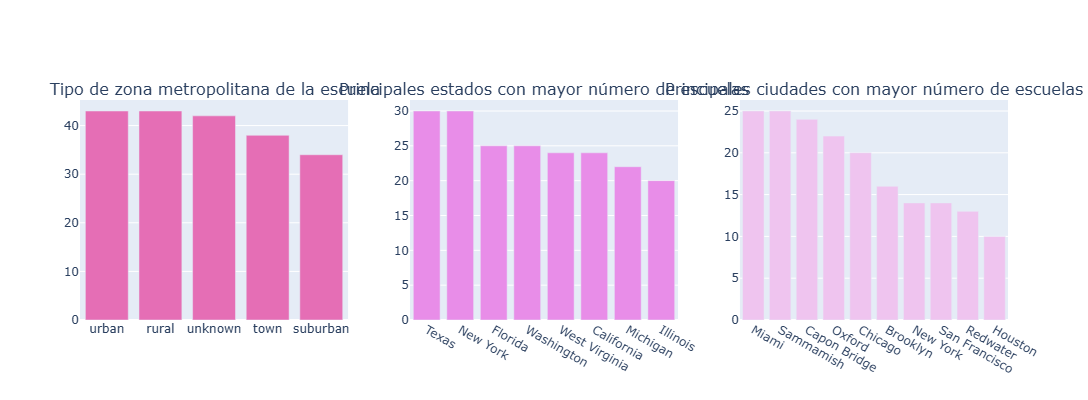

In [122]:
t1 = schools_df['School Metro Type'].value_counts()
t2 = schools_df['School State'].value_counts()
t3 = schools_df['School City'].value_counts()

trace1 = bar_ver_noagg(
    t1.index[:10],
    t1.values[:10],
    "Tipo de zona metropolitana de la escuela",
    '#e56eb5',
    None,
    None,
    0,
    rt=True
)

trace2 = bar_ver_noagg(
    t2.index[:10],
    t2.values[:10],
    "Principales estados con mayor número de escuelas",
    '#e88de8',
    None,
    None,
    0,
    rt=True
)

trace3 = bar_ver_noagg(
    t3.index[:10],
    t3.values[:10],
    "Principales ciudades con mayor número de escuelas",
    '#efc4ef',
    None,
    None,
    0,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=3,
    print_grid=False,
    subplot_titles=[
        'Tipo de zona metropolitana de la escuela',
        'Principales estados con mayor número de escuelas',
        'Principales ciudades con mayor número de escuelas'
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)
fig.append_trace(trace3, 1, 3)

fig['layout'].update(height=400, showlegend=False)

iplot(fig)

> * La mayoría de las escuelas están ubicadas en áreas suburbanas y urbanas.  
> * Nueva York, Houston y Chicago son las tres principales ciudades donde se encuentran las escuelas.  

## 5.3 Distribución del porcentaje de escuelas con almuerzo gratuito <a id='s5.3'></a>

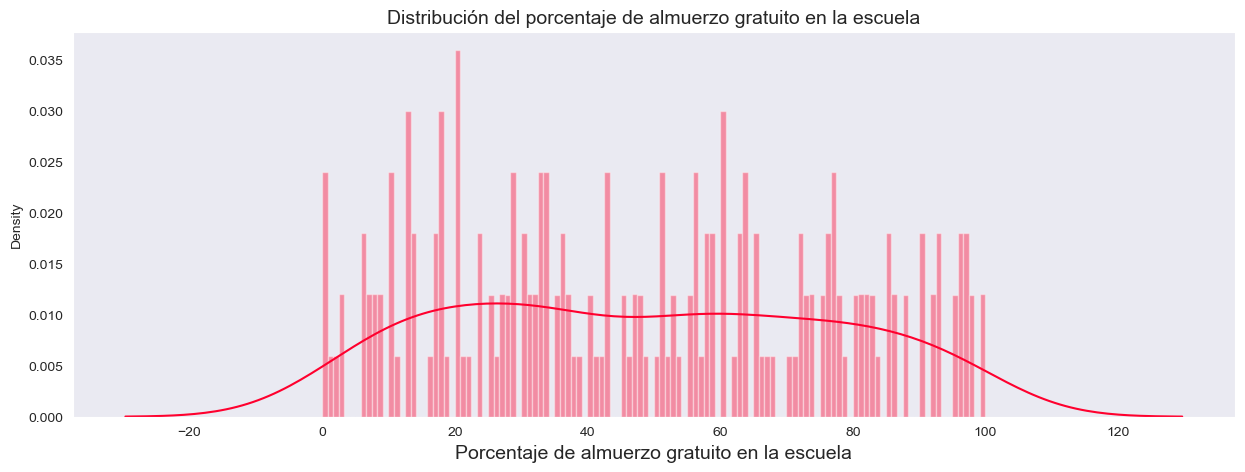

In [123]:
# Extraer porcentajes de almuerzo gratuito en las escuelas
plt.figure(figsize=(15,5))

sns.distplot(
    schools_df['School Percentage Free Lunch'].dropna(),
    bins=120,
    color="#ff002e"
)

plt.xlabel('Porcentaje de almuerzo gratuito en la escuela', fontsize=14)
plt.title("Distribución del porcentaje de almuerzo gratuito en la escuela", fontsize=14)

plt.show()

## 5.4 Qué tipos de escuelas están registrados en su mayoría <a id='s5.4'></a>

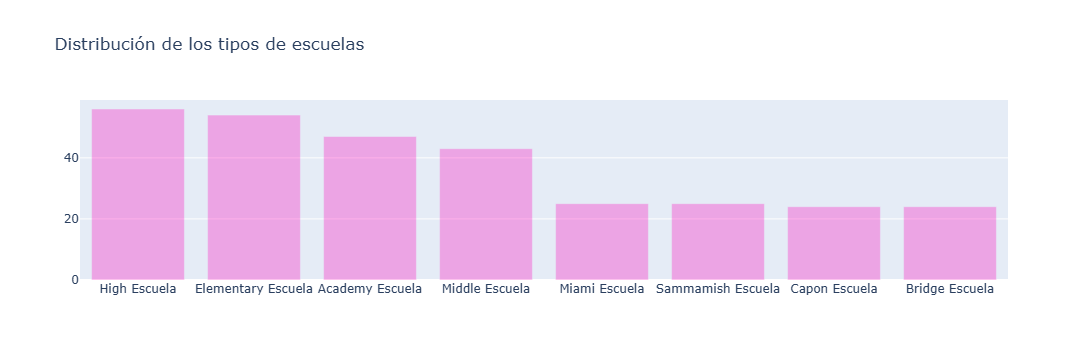

In [124]:
words = " ".join(schools_df['School Name']).split()

from collections import Counter

school_types = Counter(words).most_common(30)[1:9]
school_types = [list(x) for x in school_types]

labels = [x[0] + " Escuela" for x in school_types]
values = [x[1] for x in school_types]

trace2 = go.Bar(
    x=labels,
    y=values,
    name='Donantes por población',
    marker=dict(color='#ff00bb'),
    opacity=0.3
)

data = [trace2]

layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    title='Distribución de los tipos de escuelas',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> Una gran mayoría de las escuelas son Escuelas Primarias (con aproximadamente 35 mil escuelas), lo cual es mucho más que las Escuelas Secundarias (alrededor de 12 mil escuelas), las Escuelas Intermedias (alrededor de 9 mil escuelas) o las Escuelas de Academia (alrededor de 4 mil escuelas).

## 6. Exploración de Recursos: <a id='s6'></a>

Los datos de recursos consisten en artículos solicitados en distintos proyectos, que incluyen el nombre del artículo, la cantidad de recursos, el precio unitario y el nombre del proveedor.

## 6.1 Resumen de Recursos <a id='s6.1'></a>

In [125]:
resources_df = pd.read_csv(path+"Resources.csv")
resources_df.head(5)

# Cantidad de registros en el DataFrame de recursos
# len(resources_df)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,bdd640fb06671ad11c80317fa3b1799d,"gaiam kids stay-n-play balance ball, grey",44.0,398.73,Lakeshore Learning Materials
1,f143262fdc5c0eed8da0365bf89897b9,apple ipad wi-fi 32gb,8.0,135.61,Amazon Business
2,451b4cf36123fdf77656af7229d4beef,sony mdr zx100 blk headphones,17.0,437.49,Amazon Business
3,0e51f30dc6a7ee39c4b032ccd7c524a5,"gaiam kids stay-n-play balance ball, grey",41.0,137.81,NaN
4,0e51f30dc6a7ee39c4b032ccd7c524a5,"serta lounger, mini, sky blue",10.0,171.39,Amazon Business


> A partir de abril de 2018, se han realizado un total de 7,210,448 solicitudes de recursos por parte de profesores en diferentes proyectos.

## 6.2 Artículos más populares <a id='s6.2'></a>

> Vamos a averiguar cuáles son los artículos más populares a partir de los datos de recursos. Los artículos más solicitados son aquellos que aparecieron en un gran número de proyectos. Los artículos solicitados en grandes cantidades representan aquellos que se pidieron en grandes números.

#### 6.2.1 Artículos más solicitados de todos los tiempos

#### 6.2.2 Artículos solicitados en grandes cantidades

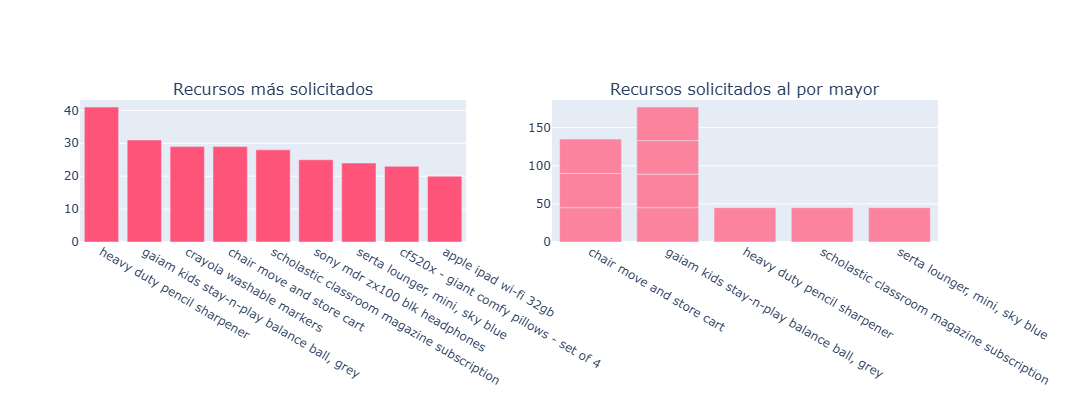

In [126]:
tdf = resources_df['Resource Item Name'].value_counts()[:15]
t = pd.DataFrame()
t['item'] = tdf.index
t['count'] = tdf.values

t1 = t.groupby('item').agg({'count': 'sum'}).reset_index()
t1 = t1.sort_values('count', ascending=True)

trace1 = bar_ver_noagg(
    list(reversed(list(t1['item']))),
    list(reversed(list(t1['count']))),
    "Recursos más solicitados",
    "#ff5479",
    400,
    400,
    0,
    rt=True
)

t = resources_df.sort_values('Resource Quantity', ascending=False).head(10)
trace2 = bar_ver_noagg(
    t['Resource Item Name'],
    t['Resource Quantity'],
    "Recursos solicitados en mayor cantidad",
    "#fc839d",
    600,
    400,
    0,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        'Recursos más solicitados',
        'Recursos solicitados al por mayor'
    ]
)
fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)
fig['layout'].update(
    height=400,
    showlegend=False,
    margin=dict(b=120)
)
iplot(fig)

> Como podemos ver, el Apple iPad (iPad Mini, Wifi, 16 o 32 GB) es el artículo más solicitado de todos los tiempos. Se ha pedido en más de 30 mil proyectos. A los profesores les interesa mucho usar la tecnología en el aula. Los **viajes** son otro de los artículos más solicitados de todos los tiempos, con más de 20 mil proyectos, lo que significa que a los profesores les interesa llevar a los estudiantes a excursiones educativas o culturales. Otros artículos populares incluyen la partición de privacidad, muebles comerciales y asientos blandos.

> Hay muchos artículos que se solicitan en grandes cantidades en uno o más proyectos. Algunos de estos artículos incluyen bloques de polietileno cruzado, deslizadores de renovación q-ball y deslizadores para sillas.

## 6.3 Artículos Más Caros <a id='s6.3'></a>

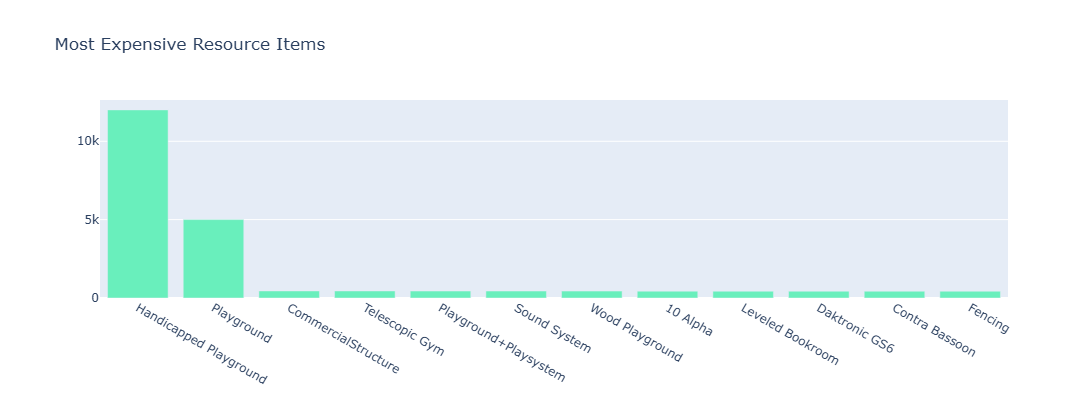

In [127]:
t = resources_df.sort_values('Resource Unit Price', ascending=False).head(15)
t1 = pd.DataFrame()
t1['item'] = t['Resource Item Name']
t1['price'] = t['Resource Unit Price']
t1['standardized'] = """Handicapped Playground,Playground,CommercialStructure,Telescopic Gym,Playground+Playsystem,Sound System,CommercialStructure,Wood Playground,Playground+Playsystem,10 Alpha,Leveled Bookroom,Daktronic GS6,Contra Bassoon,Fencing,Playground+Playsystem""".split(",")
t2 = t1.groupby('standardized').agg({'price' : 'max'}).reset_index()
t2 = t2.sort_values('price', ascending = True)
trace2 = bar_ver_noagg(list(reversed(list(t2['standardized']))), list(reversed(list(t2['price']))), "Most Expensive Resource Items", "#69efbc", 800, 400, 100)

> * Algunos de los artículos de recursos más caros en DonorsChoose son los parques infantiles, como el **Parque Infantil para Personas con Discapacidad**, que con casi 100,000 USD es el artículo de recurso más caro, seguido por la **Estructura Comercial de Little Tikes y los Gimnasios Telescópicos**.

## 6.4 Proveedores Famosos en DonorsChoose <a id='s6.4'></a>

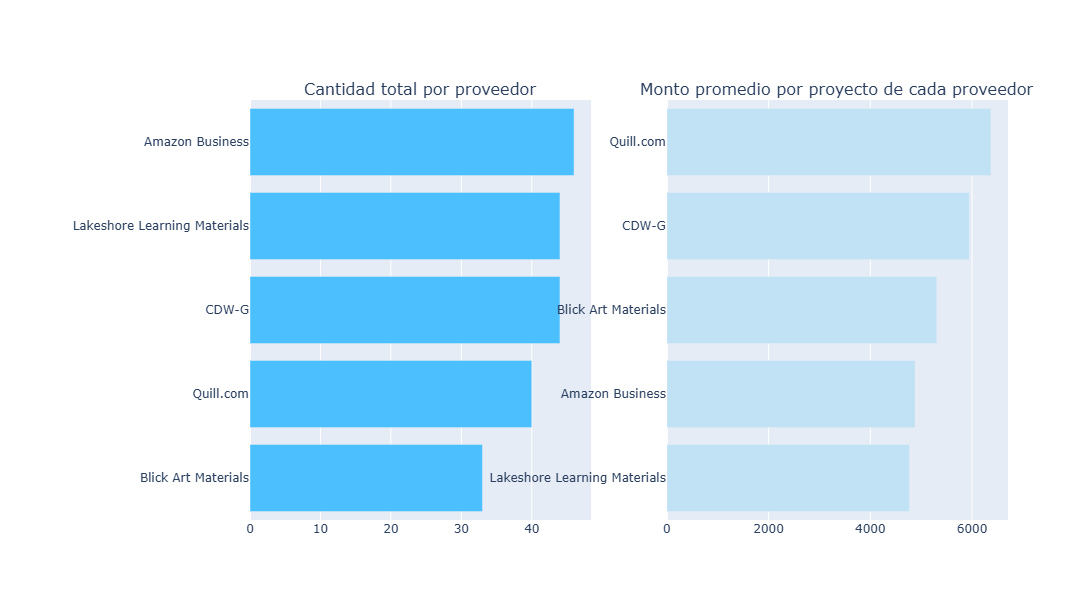

In [128]:
# Proveedores más populares
t = resources_df['Resource Vendor Name'].value_counts()

# Se obtienen los nombres y cantidades de los 15 proveedores más frecuentes
proveedores = list(reversed(list(t.index)[:15]))
cantidades = list(reversed(list(t.values)[:15]))

# Gráfica de cantidad de apariciones por proveedor
trace2 = bar_hor_noagg(
    proveedores,
    cantidades,
    "Proveedores con mayor número de recursos solicitados",
    "#4cc0ff",
    800,
    500,
    200,
    rt=True
)

# Se calcula el precio total por recurso solicitado
resources_df['Precio Total'] = resources_df['Resource Quantity'] * resources_df['Resource Unit Price']

# ¿A qué proveedor se destinó la mayor cantidad de dinero?
# tempdf = resources_df.groupby('Resource Vendor Name').agg({'Precio Total' : 'sum'}).reset_index()
# tempdf = tempdf.sort_values('Precio Total', ascending = False)[:10]
# trace1 = bar_hor_noagg(
#     list(reversed(list(tempdf['Resource Vendor Name']))),
#     list(reversed(list(tempdf['Precio Total']))),
#     "",
#     "#8dd0f4",
#     600,
#     400,
#     200,
#     rt=True
# )

# Monto promedio recibido por cada proveedor
tempdf = resources_df.groupby('Resource Vendor Name').agg({'Precio Total': 'mean'}).reset_index()
tempdf = tempdf.sort_values('Precio Total', ascending=False)[:15]

trace1 = bar_hor_noagg(
    list(reversed(list(tempdf['Resource Vendor Name']))),
    list(reversed(list(tempdf['Precio Total']))),
    "",
    "#c1e2f4",
    800,
    400,
    200,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        "Cantidad total por proveedor",
        "Monto promedio por proyecto de cada proveedor"
    ]
)

fig.append_trace(trace2, 1, 1)
fig.append_trace(trace1, 1, 2)

fig['layout'].update(
    height=600,
    showlegend=False,
    margin=dict(l=250)
)

iplot(fig)

> * La mayoría de los recursos se solicitan a **Amazon Business, con 3,2 millones** de veces que se pidió un artículo de Amazon. Amazon Business es seguido por Lakeshore Learning Materials y AKJ Education.  
> * Al comparar el costo promedio recibido por un proveedor, **MakerBot** llega al primer lugar con un costo promedio por proyecto de **2000 USD**.  
> * **Best Buy Education** es uno de esos proveedores que es popular entre los profesores y también tiene un precio promedio por proyecto significativamente más alto.

## 7. Exploración de Proyectos <a id='s7'></a>

Los datos de los proyectos consisten en todos los detalles sobre los proyectos publicados, que incluyen el id del maestro y de la escuela, el título, tipo, categoría, costo, etc., de los proyectos. Echemos un vistazo a la instantánea.

## 7.1 Instantánea de Proyectos <a id='s7.1'></a>

In [129]:
# Cargar el conjunto de datos de proyectos
projects_df = pd.read_csv(path + "Projects.csv")

# Mostrar los primeros 3 registros
projects_df.head(3)

# Cantidad de registros en el DataFrame de proyectos
# len(projects_df)

,Project ID,School ID,Teacher ID,Teacher Project Posted Sequence,Project Type,Project Title,Project Essay,Project Subject Category Tree,Project Subject Subcategory Tree,Project Grade Level Category,Project Resource Category,Project Cost,Project Posted Date,Project Current Status,Project Fully Funded Date
0,bdd640fb06671ad11c80317fa3b1799d,23b8c1e9392456de3eb13b9046685257,bd9c66b3ad3c2d6d1a3d1fa7bc8960a9,5,Teacher-Led,Anti-Bullying Begins with Me,Lorem ipsum dolor sit amet classroom school...,"Literacy & Language, Math & Science","Applied Sciences, Literature & Writing",Grades PreK-2,Books,$231.17,2014-04-22,Live,NaN
1,32e706298fadc1a606cb0fb39a1de644,8b8148f6b38a088ca65ed389b74d0fb1,96da1dac72ff5d2a386ecbe06b65a6a4,3,Teacher-Led,Anti-Bullying Begins with Me,Lorem ipsum dolor sit amet classroom school...,Music & The Arts,"Applied Sciences, Literature & Writing",Grades 3-5,Technology,$317.67,2014-11-21,Fully Funded,2014-12-01
2,d8f564135be6128e18c267976142ea7d,ce9ff57f43b7a3a69a8dca03580d7b71,89463e85759cde66bacfb3d00b1f9163,1,Teacher-Led,Technology in the Classroom,Lorem ipsum dolor sit amet classroom school...,"Applied Learning, Literacy & Language","Literacy, Mathematics",Grades 3-5,Trips,$1339.63,2015-01-11,Live,NaN


## 7.2 Cuáles son las Categorías, Subcategorías y Categorías de Recursos más frecuentes para los proyectos publicados <a id='s7.2'></a>

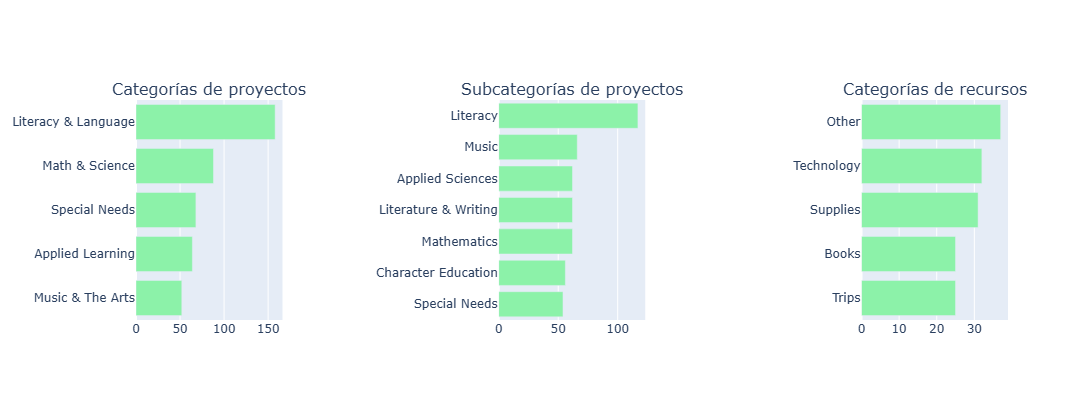

In [130]:
# Crear algunas características de fecha y tiempo
projects_df['Fecha de Publicación'] = pd.to_datetime(projects_df['Project Posted Date'])

projects_df['Año de Publicación'] = projects_df['Fecha de Publicación'].dt.year
projects_df['Mes de Publicación'] = projects_df['Fecha de Publicación'].dt.month
projects_df['Día de Publicación'] = projects_df['Fecha de Publicación'].dt.weekday
projects_df['Trimestre de Publicación'] = projects_df['Fecha de Publicación'].dt.quarter

projects_df['Fecha de Financiamiento'] = pd.to_datetime(projects_df['Project Fully Funded Date'])
projects_df['Año de Financiamiento'] = projects_df['Fecha de Financiamiento'].dt.year
projects_df['Mes de Financiamiento'] = projects_df['Fecha de Financiamiento'].dt.month
projects_df['Día de Financiamiento'] = projects_df['Fecha de Financiamiento'].dt.weekday
projects_df['Trimestre de Financiamiento'] = projects_df['Fecha de Financiamiento'].dt.quarter

projects_df['Tiempo de Financiamiento'] = (
    projects_df['Fecha de Financiamiento'] - projects_df['Fecha de Publicación']
)

# Categorías principales de proyectos
t = projects_df['Project Subject Category Tree'].value_counts()
x = list(t.index)
y = list(t.values)

r = {}

for i, val in enumerate(x):
    for each in val.split(","):
        x1_temp = each.strip()

        if x1_temp not in r:
            r[x1_temp] = y[i]

        r[x1_temp] += y[i]

sorted_x = list(
    sorted(r.items(), key=operator.itemgetter(1), reverse=True)
)[:10]

x1 = [a[0] for a in sorted_x][::-1]
y1 = [a[1] for a in sorted_x][::-1]

# Subcategorías principales de proyectos
t1 = projects_df['Project Subject Subcategory Tree'].value_counts()

x2 = list(t1.index)
y2 = list(t1.values)

r = {}

for i, val in enumerate(x2):
    for each in val.split(","):
        x1_ = each.strip()

        if x1_ not in r:
            r[x1_] = y2[i]

        r[x1_] += y2[i]

x2 = r.keys()
y2 = r.values()

sorted_x = list(
    sorted(r.items(), key=operator.itemgetter(1), reverse=True)
)[:10]

x2 = [a[0] for a in sorted_x][::-1]
y2 = [a[1] for a in sorted_x][::-1]

# Categorías de recursos
t = projects_df['Project Resource Category'].value_counts()
x3 = list(t.index[::-1])[:10]
y3 = list(t.values[::-1])[:10]

trace1 = bar_hor_noagg(
    x1,
    y1,
    "",
    "#8cf2a9",
    600,
    400,
    10,
    rt=True
)

trace2 = bar_hor_noagg(
    x2,
    y2,
    "",
    "#8cf2a9",
    600,
    400,
    10,
    rt=True
)

trace3 = bar_hor_noagg(
    x3,
    y3,
    "",
    "#8cf2a9",
    600,
    400,
    10,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=5,
    print_grid=False,
    subplot_titles=[
        'Categorías de proyectos',
        '',
        'Subcategorías de proyectos',
        '',
        'Categorías de recursos'
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 3)
fig.append_trace(trace3, 1, 5)

fig['layout'].update(
    height=400,
    showlegend=False,
    margin=dict(l=120)
)

iplot(fig)

> La gran mayoría de los proyectos (más de 800 mil) pertenecen a la categoría principal de **Alfabetización y Lenguaje**. **Matemáticas y Ciencias** es la segunda categoría más popular. Un número comparativamente menor de proyectos se ha publicado sobre Cuidado y Hambre desde 2013.  
Entre las subcategorías, Alfabetización, Matemáticas y Escritura son las subcategorías más comunes de los proyectos publicados por los docentes, mientras que se publican menos proyectos en la categoría de Desarrollo Temprano y Salud. **Tecnología Educativa, Rincones de Lectura, Escritorios y Almacenamiento** son las principales categorías de recursos solicitadas por los docentes.  

## 7.3 ¿Cuál es la distribución del tipo de proyecto y del estado actual del proyecto? <a id='s7.3'></a>

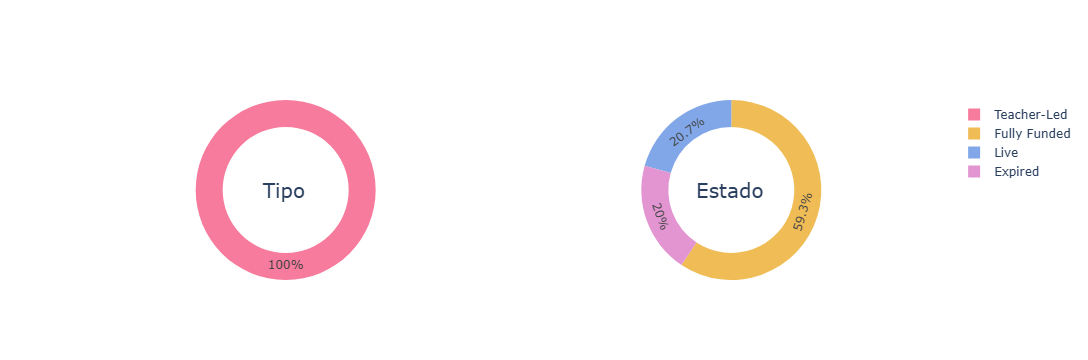

In [131]:
# Obtener la cantidad de proyectos por tipo
t = projects_df['Project Type'].value_counts()
valores1 = t.values
etiquetas1 = t.index

# Obtener la cantidad de proyectos por estado actual
t = projects_df['Project Current Status'].value_counts()
valores2 = t.values
etiquetas2 = t.index

domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

fig = {
  "data": [
    {
      "values": valores1,
      "labels": etiquetas1,
      "domain": {"x": [0, .48]},
      "marker": dict(colors=["#f77b9c", '#ab97db', '#b0b1b2']),
      "name": "Tipo de proyecto",
      "hoverinfo": "label+percent+name",
      "hole": .7,
      "type": "pie"
    },
    {
      "values": valores2,
      "labels": etiquetas2,
      "marker": dict(colors=["#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
      "name": "Estado del proyecto",
      "hole": .7,
      "type": "pie"
    }
  ],
  "layout": {
      # "title": "Tipo de proyecto y estado del proyecto",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Tipo",
                "x": 0.21,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Estado",
                "x": 0.8,
                "y": 0.5
            }
        ]
    }
}

iplot(fig, filename='donut')

Aparte de los proyectos dominados por el maestro, un número significativamente menor de proyectos también son publicados por estudiantes o servicios de desarrollo profesional. Los datos muestran que alrededor del 75% de todos los proyectos publicados han sido completamente financiados, mientras que el 21% de ellos han expirado. Hasta mayo de 2018, hay aproximadamente 42 mil proyectos activos en donorschoose.

## 7.4 ¿En qué días se publicaron y financiaron más proyectos? <a id='s7.4'></a>

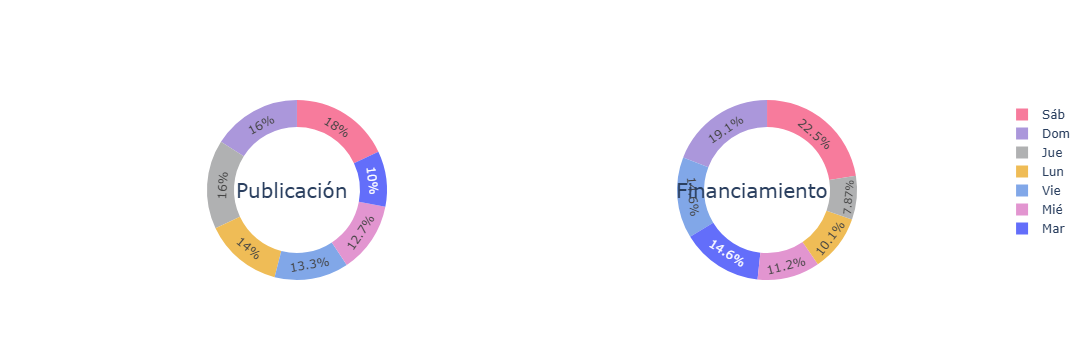

In [132]:
t1 = projects_df['Día de Publicación'].value_counts()
t2 = projects_df['Día de Financiamiento'].value_counts()

# Traducción de los días de la semana
mapp = {
    0: 'Lun',
    1: 'Mar',
    2: 'Mié',
    3: 'Jue',
    4: 'Vie',
    5: 'Sáb',
    6: 'Dom'
}

valores1 = t1.values
etiquetas1 = t1.index
etiquetas1 = [mapp[x] for x in etiquetas1]

valores2 = t2.values
etiquetas2 = t2.index
etiquetas2 = [mapp[x] for x in etiquetas2]

mapa_temporal = {}

for j, b in enumerate(etiquetas2):
    mapa_temporal[b] = valores2[j]

# print(mapa_temporal)
# print(etiquetas1)

valores2_corregidos = [mapa_temporal[c] for c in etiquetas1]

# print(valores2_corregidos)

domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

fig = {
  "data": [
    {
      "values": valores1,
      "labels": etiquetas1,
      "domain": {"x": [0, .48]},
      "marker": dict(
          colors=["#f77b9c", '#ab97db', '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]
      ),
      "name": "Día de publicación",
      "hoverinfo": "label+percent+name",
      "hole": .7,
#      "textinfo": "text",
      "type": "pie"
    },
    {
      "values": valores2_corregidos,
      "labels": etiquetas1,
      "marker": dict(
          colors=["#f77b9c", '#ab97db', '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]
      ),
      "domain": {"x": [.52, 1]},
#      "text": "CO2",
      "textposition": "inside",
      "name": "Día de financiamiento",
#      "text": valores2,
#      "textinfo": "text",
      "hole": .7,
      "type": "pie"
    }
  ],

  "layout": {
#     "title": "Días de publicación y financiamiento",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Publicación",
                "x": 0.17,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Financiamiento",
                "x": 0.83,
                "y": 0.5
            }
        ]
    }
}

iplot(fig, filename='donut')

> Los maestros generalmente han publicado los días finales de las semanas - viernes (16%), sábado (16%) y domingo (17%). Mientras que los lunes se han financiado y cerrado la mayor cantidad de proyectos.

## 7.5 ¿En qué trimestres se publican y financian los proyectos? <a id='s7.5'></a>

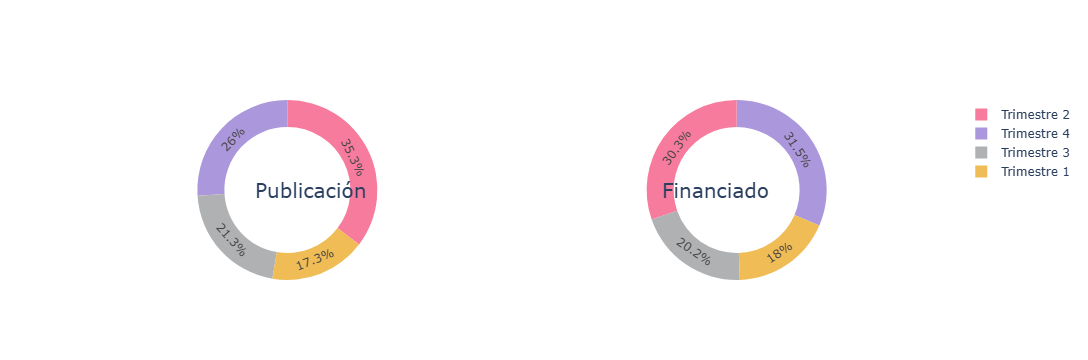

In [133]:
t1 = projects_df['Trimestre de Publicación'].value_counts()
t2 = projects_df['Trimestre de Financiamiento'].value_counts()

# Traducción de los trimestres
mappq = {
    1.0: 'Trimestre 1',
    2.0: 'Trimestre 2',
    3.0: 'Trimestre 3',
    4.0: 'Trimestre 4'
}

valores1 = t1.values
etiquetas1 = t1.index
etiquetas1 = [mappq[x] for x in etiquetas1]

valores2 = t2.values
etiquetas2 = t2.index
etiquetas2 = [mappq[x] for x in etiquetas2]

mapa_temporal = {}

for j, b in enumerate(etiquetas2):
    mapa_temporal[b] = valores2[j]

# print(mapa_temporal)
# print(etiquetas1)

valores2_corregidos = [mapa_temporal[c] for c in etiquetas1]

# print(valores2_corregidos)

domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

fig = {
  "data": [
    {
      "values": valores1,
      "labels": etiquetas1,
      "domain": {"x": [0, .48]},
      "marker": dict(
          colors=["#f77b9c", '#ab97db', '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]
      ),
      "name": "Trimestre de publicación",
#     "hoverinfo":"label+percent+name",
      "hole": .7,
#     "textinfo": "text",
      "type": "pie"
    },
    {
      "values": valores2_corregidos,
      "labels": etiquetas1,
      "marker": dict(
          colors=["#f77b9c", '#ab97db', '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]
      ),
      "domain": {"x": [.52, 1]},
#     "text":"CO2",
      "textposition": "inside",
      "name": "Trimestre de financiamiento",
#     "text": valores2,
#     "textinfo": "text",
      "hole": .7,
      "type": "pie"
    }
  ],

  "layout": {
#     "title":"Trimestre de publicación y financiamiento",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Publicación",
                "x": 0.2,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Financiado",
                "x": 0.8,
                "y": 0.5
            }
        ]
    }
}

iplot(fig, filename='donut')

> El tercer trimestre, es decir, julio, agosto y septiembre, es el período en el que los maestros han publicado la mayor cantidad de proyectos y lo mismo ocurre en su trimestre siguiente, es decir, el cuarto trimestre, cuando la mayoría de los proyectos han sido financiados y cerrados.

## 7.6 ¿En qué meses se publicaron los proyectos? <a id='s7.6'></a>

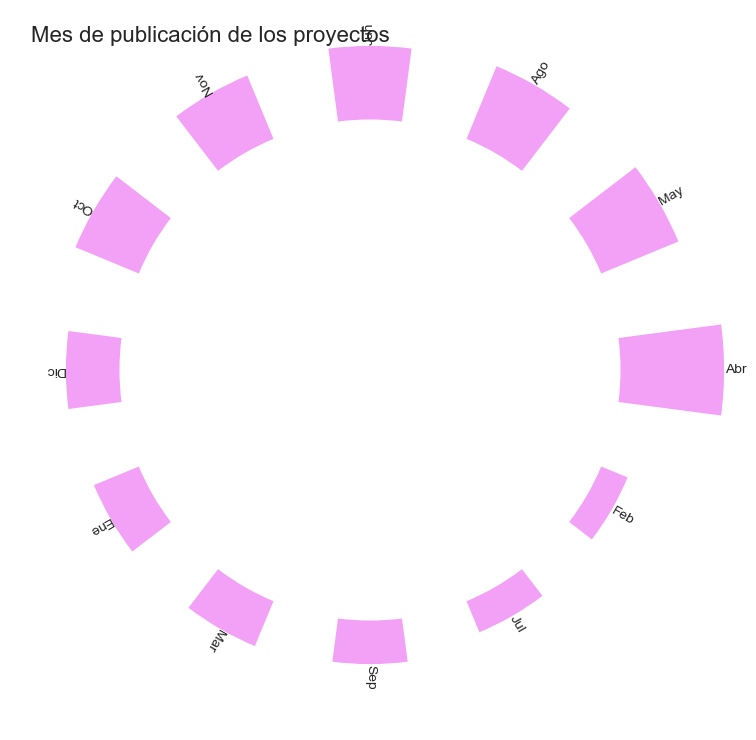

In [134]:
t = projects_df['Mes de Publicación'].value_counts()

cantidades = list(t.values)

etiquetas = list(t.index)

# Traducción de los meses
mapp1 = {
    1: 'Ene',
    2: 'Feb',
    3: 'Mar',
    4: 'Abr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Ago',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dic'
}

etiquetas = [mapp1[x] for x in etiquetas]

iN = len(cantidades)
arrCnts = np.array(cantidades)

theta = np.arange(0, 2 * np.pi, 2 * np.pi / iN)
width = (2 * np.pi) / iN * 0.5
bottom = 50

fig = plt.figure(figsize=(8, 8))
ax = fig.add_axes([0.2, 0.1, 1, 0.9], polar=True)

fig.suptitle('Mes de publicación de los proyectos', fontsize=16)

bars = ax.bar(
    theta,
    arrCnts,
    width=width,
    bottom=bottom,
    color='#f3a0f7'
)

plt.axis('off')

rotations = np.rad2deg(theta)

for x, bar, rotation, label in zip(theta, bars, rotations, etiquetas):
    lab = ax.text(
        x,
        bottom + bar.get_height(),
        label,
        ha='left',
        va='center',
        rotation=rotation,
        rotation_mode="anchor",
    )

plt.show()

>En el tercer trimestre, el mayor número de proyectos se publicó en el mes de septiembre, seguido de agosto. El menor número de proyectos se publicó en junio.

## 7.7 En qué año se publicaron los proyectos <a id='s7.7'></a>

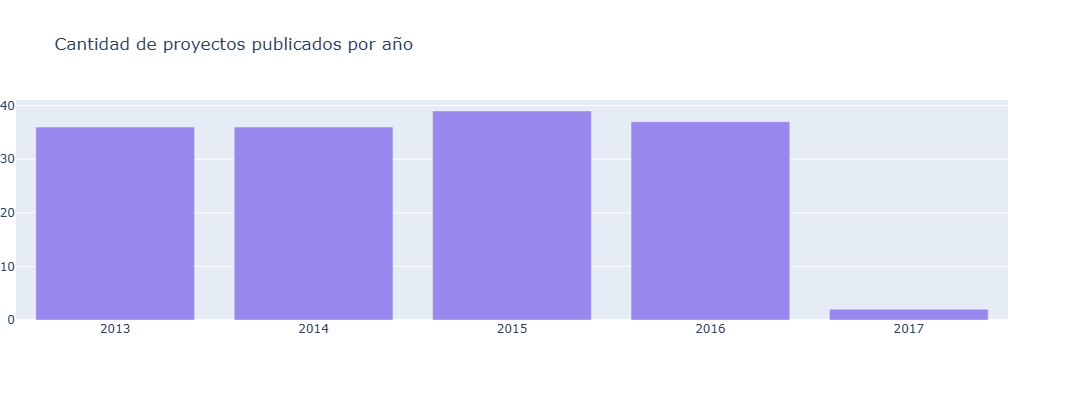

In [135]:
# Cantidad de proyectos publicados por año
t = projects_df.groupby('Año de Publicación').agg({'Mes de Publicación': 'count'}).reset_index()

t = t.sort_values('Año de Publicación')

trace2 = bar_ver_noagg(
    t['Año de Publicación'],
    t['Mes de Publicación'],
    "Cantidad de proyectos publicados por año",
    "#9887ed",
    None,
    400,
    0
)

>El número de proyectos en DonorsChoose ha estado aumentando constantemente durante los últimos 5 años. Unos 300 mil proyectos se publicaron en 2017.

## 7.8 ¿En qué año y mes el costo del proyecto es más alto? <a id='s7.8'></a>

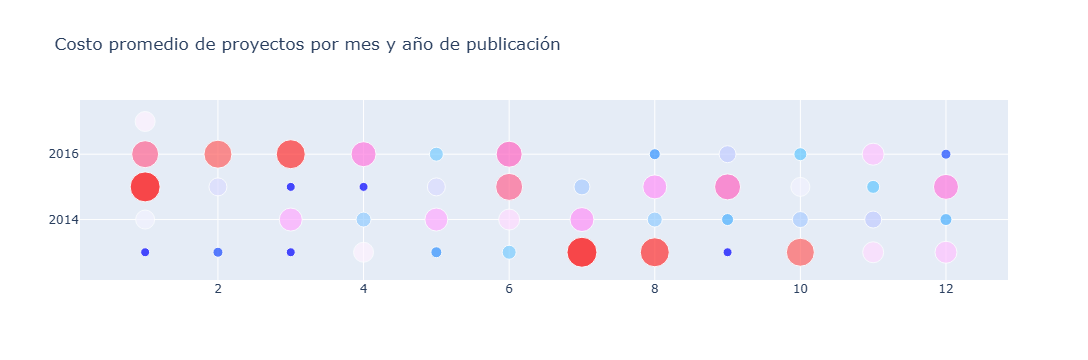

In [136]:
# Tabla cruzada entre el estado actual del proyecto y el año de publicación
tabla_anual = pd.crosstab(
    projects_df["Project Current Status"],
    projects_df["Año de Publicación"]
).reset_index()

from itertools import zip_longest

# Convertir el costo del proyecto a formato numérico
projects_df['Costo'] = projects_df['Project Cost'].apply(
    lambda x: float(str(x).replace(",", "").replace("$", ""))
)

def cbp(df, col1, col2, aggcol, func, title, cs, bottom_margin=None):

    tempdf = df.groupby([col1, col2]).agg({aggcol: func}).reset_index()

    tempdf[aggcol] = tempdf[aggcol].apply(lambda x: int(x))

    tempdf = tempdf.sort_values(aggcol, ascending=False)

    sizes = list(reversed([i for i in range(10, 31)]))
    intervals = int(len(tempdf) / len(sizes))

    size_array = [9] * len(tempdf)

    st = 0

    for i, size in enumerate(sizes):
        for j in range(st, st + intervals):
            size_array[j] = size

        st = st + intervals

    tempdf['Tamaño'] = size_array

    # tempdf = tempdf.sample(frac=1).reset_index(drop=True)

    colores = list(tempdf['Tamaño'])

    trace1 = go.Scatter(
        x=tempdf[col1],
        y=tempdf[col2],
        mode='markers',
        text=tempdf[aggcol],
        marker=dict(
            size=tempdf['Tamaño'],
            color=colores,
            colorscale=cs
        )
    )

    data = [trace1]

    if bottom_margin:
        layout = go.Layout(
            title=title,
            margin=dict(b=150)
        )
    else:
        layout = go.Layout(
            title=title
        )

    fig = go.Figure(
        data=data,
        layout=layout
    )

    iplot(fig)

cbp(
    projects_df,
    'Mes de Publicación',
    'Año de Publicación',
    'Costo',
    'mean',
    'Costo promedio de proyectos por mes y año de publicación',
    'Picnic'
)

>* Septiembre de 2014 vio un gran número de proyectos publicados con un alto costo promedio. En 2015, los meses de abril, mayo, septiembre y octubre tuvieron proyectos con un costo elevado.  

## 7.9 ¿En qué año y categoría de grado, el costo del proyecto es el más alto? <a id='s7.9'></a>

In [137]:
temp_check = projects_df.groupby(['Project Grade Level Category', 'Año de Publicación']).size()
print(temp_check)

Project Grade Level Category  Año de Publicación
Grades 3-5                    2013                   8
                              2014                  11
                              2015                  10
                              2016                   9
                              2017                   1
Grades 6-8                    2013                  10
                              2014                  10
                              2015                  11
                              2016                   9
                              2017                   1
Grades 9-12                   2013                   8
                              2014                   8
                              2015                   9
                              2016                   4
Grades PreK-2                 2013                  10
                              2014                   7
                              2015                   9
                

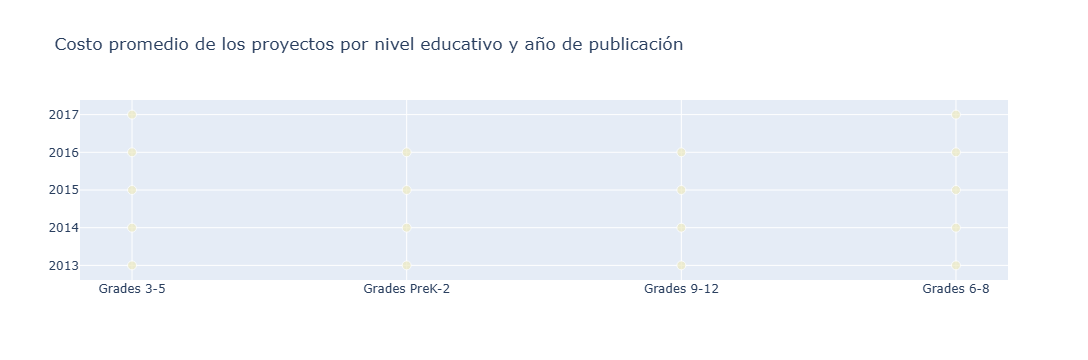

In [138]:
cbp(
    projects_df,
    'Project Grade Level Category',
    'Año de Publicación',
    'Costo',
    'mean',
    'Costo promedio de los proyectos por nivel educativo y año de publicación',
    'Earth'
)

>Para los grados 6-8 y 9-12, los proyectos con altos costos fueron en el año 2015; para los grados 3-5 y PreK-2 fueron en 2014,  

## 7.10 Categorías de Grado y Categorías de Recursos con los costos de proyecto más altos <a id='s7.10'></a>

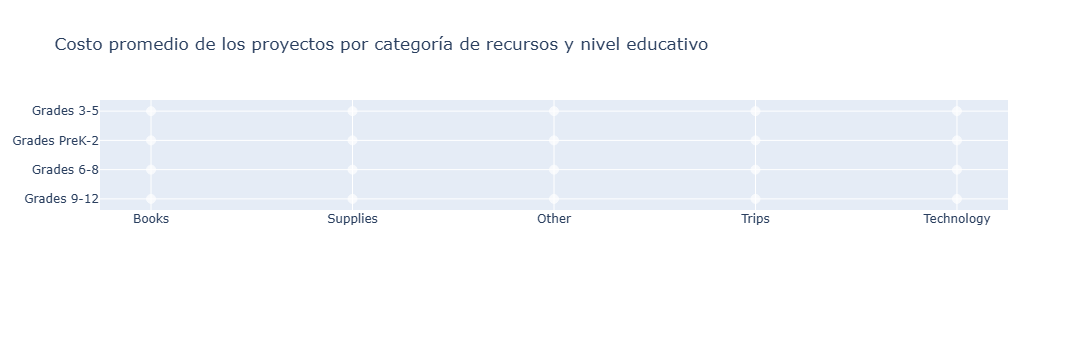

In [139]:
cbp(
    projects_df,
    'Project Resource Category',
    'Project Grade Level Category',
    'Costo',
    'mean',
    'Costo promedio de los proyectos por categoría de recursos y nivel educativo',
    'Picnic',
    bottom_margin=150
)

>* Los viajes se organizan principalmente para los grados superiores, es decir, del 9 al 12, seguidos por los grados 6-8 y luego 3-5. Los grados PreK-2 tienen un número significativamente menor en comparación con otros grados. Los visitantes son otro recurso clave para todos los grados.

## 7.11 ¿Cómo varía el estado del proyecto según el año? <a id='s7.11'></a>

In [140]:
# Crear columnas de fecha
projects_df['Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])
projects_df['Posted Year'] = projects_df['Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Posted Date'].dt.weekday
projects_df['Posted Quarter'] = projects_df['Posted Date'].dt.quarter

projects_df['Funded Date'] = pd.to_datetime(projects_df['Project Fully Funded Date'])
projects_df['Funded Year'] = projects_df['Funded Date'].dt.year
projects_df['Funded Month'] = projects_df['Funded Date'].dt.month
projects_df['Funded Day'] = projects_df['Funded Date'].dt.weekday
projects_df['Funded Quarter'] = projects_df['Funded Date'].dt.quarter
projects_df['Funding Time'] = projects_df['Funded Date'] - projects_df['Posted Date']

In [141]:
year_tab = pd.crosstab(projects_df["Project Current Status"], projects_df["Posted Year"]).reset_index()

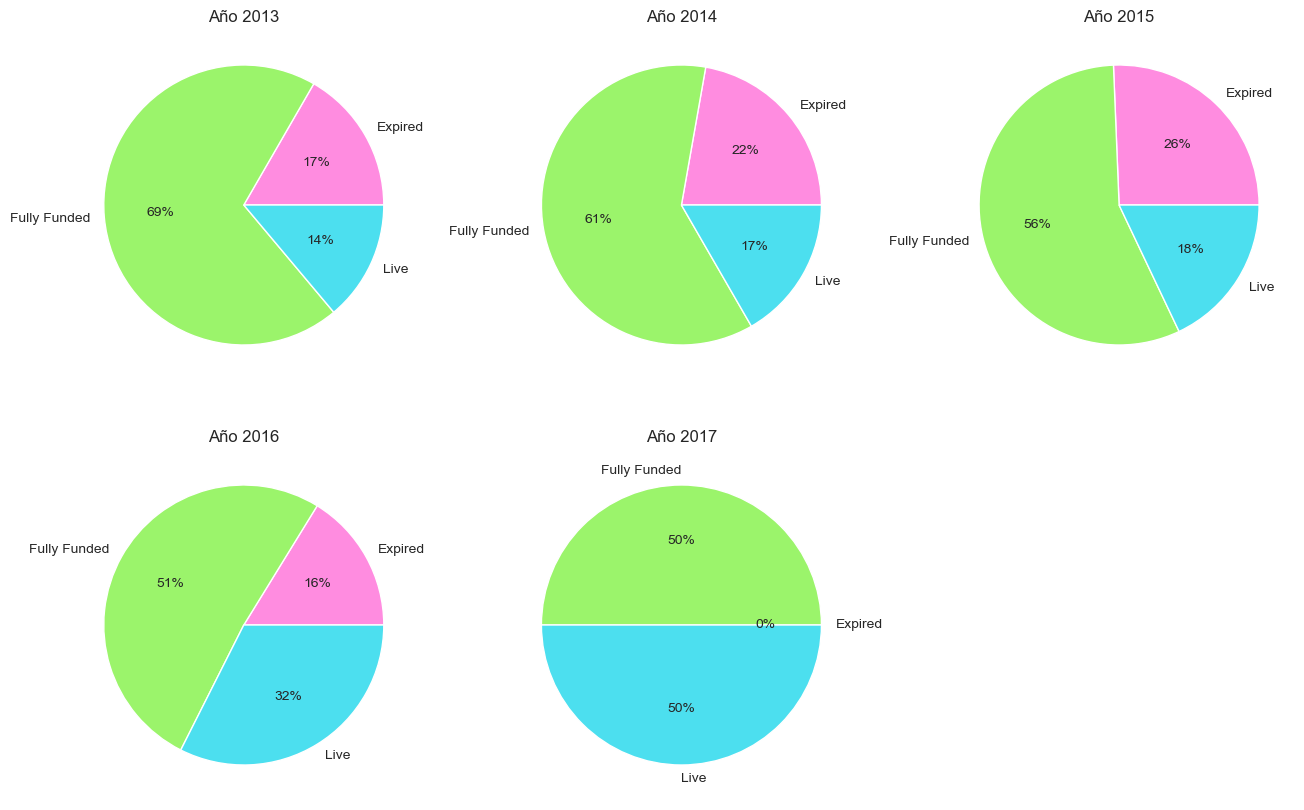

In [142]:
# Años a analizar
años = [2013, 2014, 2015, 2016, 2017]

plt.figure(figsize=(16, 10))

for año, posicion in zip_longest(años, range(len(años))):

    plt.subplot(2, 3, posicion + 1)

    plt.pie(
        year_tab[año],
        labels=year_tab["Project Current Status"].tolist(),
        autopct="%1.0f%%",
        colors=["#ff8ce0", "#9bf46b", "#4cdfef"],
        wedgeprops={"linewidth": 1, "edgecolor": "white"}
    )

    plt.title(f"Año {año}")

> Un vistazo año tras año a los datos muestra que alrededor del 70% de los proyectos totales publicados en DonorsChoose en un año se financian completamente. Ha habido una tendencia creciente en el porcentaje de proyectos totalmente financiados por año, excepto en 2016, cuando el número de proyectos completamente financiados disminuyó un 6% respecto al año anterior. 2017 y 2015 fueron los mejores años en términos de proporción de proyectos totalmente financiados, cuando aproximadamente el 78% de los proyectos se financiaron completamente.

## 7.12 Durante cuántos días los proyectos permanecieron activos <a id='s7.12'></a>

Text(0.5, 1.0, 'Tiempo de finalización de proyectos completamente financiados')

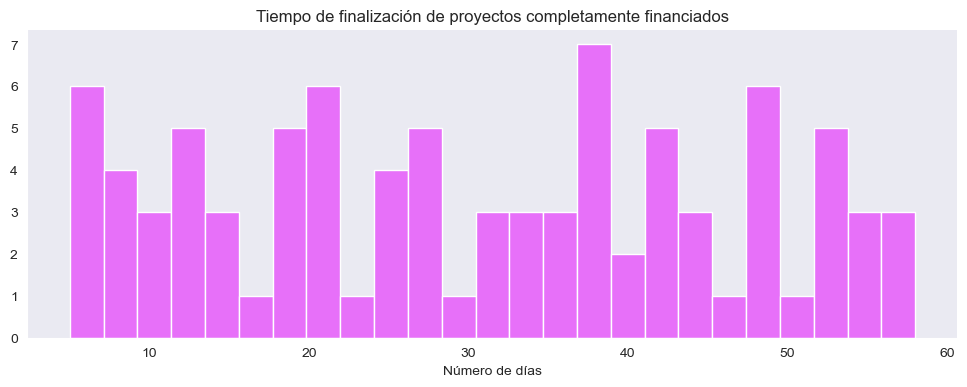

In [143]:
# Seleccionar únicamente los proyectos completamente financiados
t = projects_df[projects_df['Project Current Status'] == "Fully Funded"]

# Convertir el tiempo de financiamiento a días enteros
t['Tiempo de Financiamiento'] = t['Tiempo de Financiamiento'].apply(
    lambda x: int(str(x).split()[0])
)

plt.figure(figsize=(12,4))

ax = t['Tiempo de Financiamiento'].hist(
    bins=25,
    edgecolor='white',
    color="#e770f9"
)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Número de días')
plt.title('Tiempo de finalización de proyectos completamente financiados')

>* Un mayor número de proyectos tiene un tiempo de finalización de menos de 3 días. Aproximadamente "55000 proyectos" en el pasado fueron financiados con éxito en un día, mientras que hay alrededor de "48627 proyectos" que se cerraron el mismo día en que fueron publicados. El mayor número de días para cualquier proyecto es igual a 288 días, el cual fue para el proyecto titulado **"Empty Bowls, Full Hearts."**. Este proyecto tenía un costo estimado de USD 1982 y fue publicado por la **Escuela Primaria Harrison Park** en Michigan. 

## 7.13 ¿Cómo varía la proporción de proyectos financiados vs no financiados por estado? <a id='s7.13'></a>

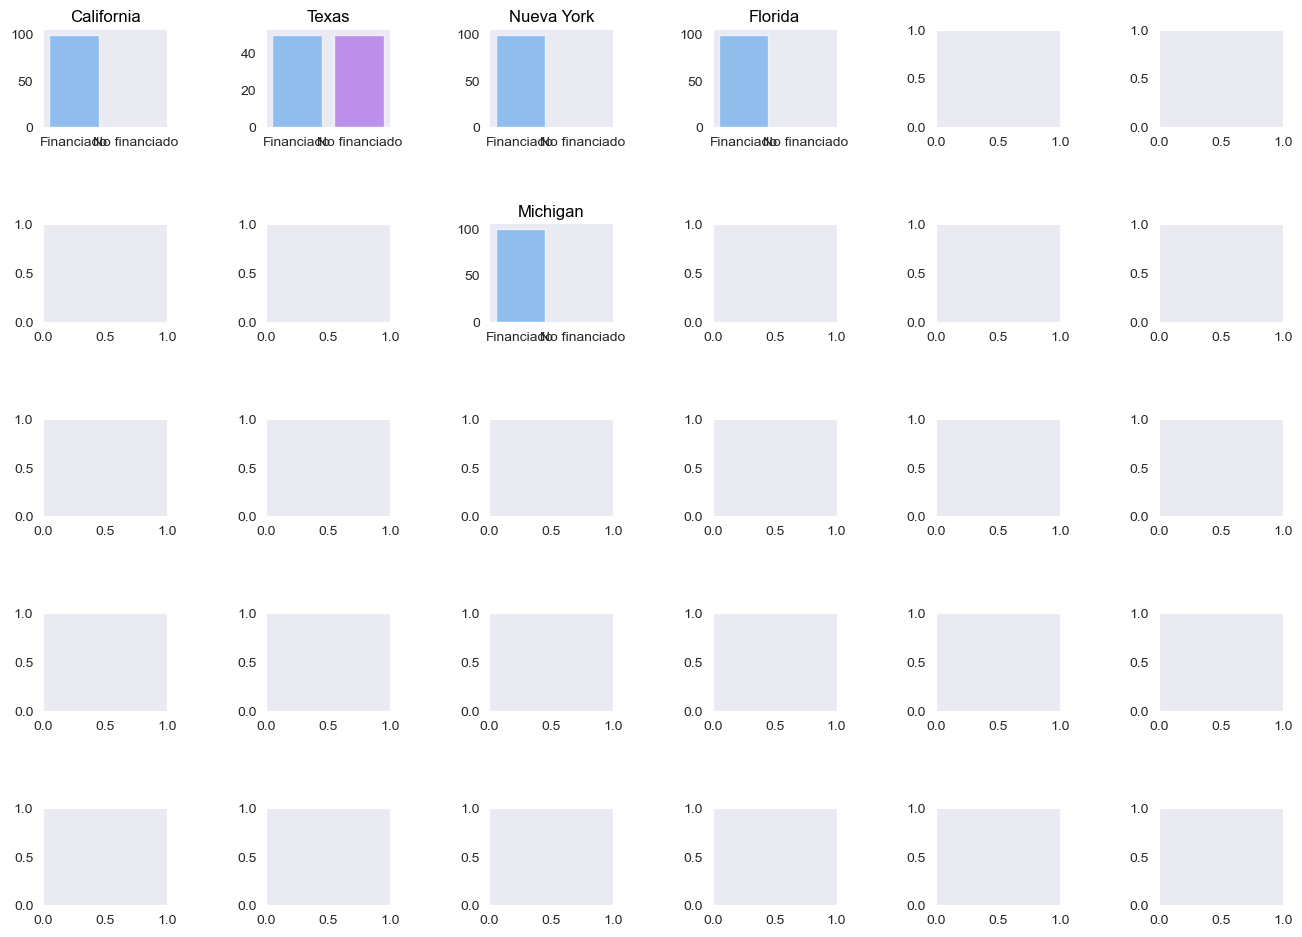

In [144]:
# Unir la información de proyectos y escuelas mediante el identificador de la escuela
projsch_df = projects_df.merge(schools_df, on="School ID")

# Estados a analizar
states = [
    u'California', u'Texas', u'New York', u'Florida', u'North Carolina',
    u'Illinois', u'Georgia', u'South Carolina', u'Michigan',
    u'Pennsylvania', u'Massachusetts', u'Indiana', u'Oklahoma',
    u'Washington', u'Ohio', u'New Jersey', u'Missouri', u'Arizona',
    u'Virginia', u'Louisiana', u'Tennessee', u'Utah', u'Wisconsin',
    u'Connecticut', u'Alabama', u'Maryland', u'Nevada', u'Oregon',
    u'Colorado', u'Mississippi', u'Minnesota', u'Kentucky', u'Arkansas',
    u'Hawaii', u'Idaho', u'Maine', u'Kansas', u'Iowa',
    u'New Mexico', u'West Virginia', u'Alaska',
    u'New Hampshire', u'Delaware', u'Rhode Island', u'Nebraska',
    u'South Dakota', u'Montana', u'North Dakota', u'Vermont', u'Wyoming'
][:30]

# Traducción de nombres de estados para mostrarlos en español
traduccion_estados = {
    'California': 'California',
    'Texas': 'Texas',
    'New York': 'Nueva York',
    'Florida': 'Florida',
    'North Carolina': 'Carolina del Norte',
    'Illinois': 'Illinois',
    'Georgia': 'Georgia',
    'South Carolina': 'Carolina del Sur',
    'Michigan': 'Michigan',
    'Pennsylvania': 'Pensilvania',
    'Massachusetts': 'Massachusetts',
    'Indiana': 'Indiana',
    'Oklahoma': 'Oklahoma',
    'Washington': 'Washington',
    'Ohio': 'Ohio',
    'New Jersey': 'Nueva Jersey',
    'Missouri': 'Misuri',
    'Arizona': 'Arizona',
    'Virginia': 'Virginia',
    'Louisiana': 'Luisiana',
    'Tennessee': 'Tennessee',
    'Utah': 'Utah',
    'Wisconsin': 'Wisconsin',
    'Connecticut': 'Connecticut',
    'Alabama': 'Alabama',
    'Maryland': 'Maryland',
    'Nevada': 'Nevada',
    'Oregon': 'Oregón',
    'Colorado': 'Colorado',
    'Mississippi': 'Misisipi',
    'Minnesota': 'Minnesota',
    'Kentucky': 'Kentucky',
    'Arkansas': 'Arkansas',
    'Hawaii': 'Hawái',
    'Idaho': 'Idaho',
    'Maine': 'Maine',
    'Kansas': 'Kansas',
    'Iowa': 'Iowa',
    'New Mexico': 'Nuevo México',
    'West Virginia': 'Virginia Occidental',
    'Alaska': 'Alaska',
    'New Hampshire': 'Nuevo Hampshire',
    'Delaware': 'Delaware',
    'Rhode Island': 'Rhode Island',
    'Nebraska': 'Nebraska',
    'South Dakota': 'Dakota del Sur',
    'Montana': 'Montana',
    'North Dakota': 'Dakota del Norte',
    'Vermont': 'Vermont',
    'Wyoming': 'Wyoming'
}

import itertools

length = len(states)

plt.figure(figsize=(16,24))

for estado, posicion in itertools.zip_longest(states, range(length)):

    plt.subplot(10, 6, posicion + 1)

    t = dict(
        projsch_df[
            projsch_df['School State'] == estado
        ]['Project Current Status'].value_counts()
    )
    # Adaptación a la nueva versión del conjunto de datos, usando .get() para evitar errores si falta algún estado
    fully_funded = t.get('Fully Funded', 0)
    no_financiado = t.get('Expired', 0)
    total = fully_funded + no_financiado

    if total == 0:
        continue  # Si el estado no tiene datos de estos dos estatus, se salta

    t1 = {
        'Financiado': float(fully_funded) * 100 / total,
        'No financiado': float(no_financiado) * 100 / total
    }

    ax = sns.barplot(
        x=list(t1.keys()),
        y=list(t1.values()),
        alpha=.7,
        palette='cool'
    )

    ax.grid(False)

#   plt.yticks(np.arange(0,100,10))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.subplots_adjust(
        wspace=.8,
        hspace=1
    )

    plt.title(
        traduccion_estados.get(estado, estado),
        color="black"
    )

>* Algunos de los estados donde el porcentaje de proyectos expirados o no financiados es menor son 'Georgia', 'South Carolina' y 'Mississippi'.

## 7.14 ¿Cuál es el costo promedio de los proyectos según el tipo de zona metropolitana de la escuela y la categoría de recurso solicitada? <a id='s7.14'></a>

In [145]:
cbp(
    projsch_df,
    'Project Resource Category',
    'School Metro Type',
    'Costo',
    'mean',
    'Costo promedio de los proyectos según la categoría de recursos y el tipo de zona escolar',
    'Rainbow',
    bottom_margin=150
)

>Los viajes y visitantes siempre son las categorías más caras entre todos los diferentes tipos de Metro Escolar. "Ciudades" tiene el costo promedio más alto para los proyectos en los que se solicitaron recursos pertenecientes a Equipos de Deportes y Ejercicio.

## 7.15 ¿Cuál es el costo promedio de los proyectos según el tipo de Metro Escolar y la categoría de nivel de grado de los proyectos? <a id='s7.15'></a>

In [146]:
cbp(
    projsch_df,
    'Project Grade Level Category',
    'School Metro Type',
    'Costo',
    'mean',
    'Costo promedio de los proyectos según el nivel educativo y el tipo de zona escolar',
    'Rainbow'
)

>Los grados 9-12 tienen el costo promedio de proyectos más alto en comparación con cualquier otra categoría de grado. Entre ellos, los tipos de metro suburbano tienen los precios de proyecto más altos, mientras que los pueblos tienen los más bajos.

## 8. Procesamiento de Lenguaje Natural para Perfilado de Proyectos <a id='s8'></a>

Se puede construir mucho entendimiento usando el análisis de texto de los ensayos de los proyectos. Vamos a realizar un análisis de texto / procesamiento de lenguaje natural básico para extraer la información relevante de los ensayos de los proyectos. Para este propósito, me estoy enfocando en un subconjunto de proyectos recientes desde abril de 2018.

## 8.1 Limpieza de Texto <a id='s8.1'></a>

Escribe una función de utilidad que normalice el texto y elimine el ruido. Esta función de limpieza de texto realiza la eliminación de palabras vacías del texto y la eliminación de signos de puntuación.

In [147]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yulid\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [148]:
print([col for col in projects_df.columns if 'need' in col.lower() or 'statement' in col.lower()])

[]


In [149]:
print(projects_df.columns.tolist())

['Project ID', 'School ID', 'Teacher ID', 'Teacher Project Posted Sequence', 'Project Type', 'Project Title', 'Project Essay', 'Project Subject Category Tree', 'Project Subject Subcategory Tree', 'Project Grade Level Category', 'Project Resource Category', 'Project Cost', 'Project Posted Date', 'Project Current Status', 'Project Fully Funded Date', 'Fecha de Publicación', 'Año de Publicación', 'Mes de Publicación', 'Día de Publicación', 'Trimestre de Publicación', 'Fecha de Financiamiento', 'Año de Financiamiento', 'Mes de Financiamiento', 'Día de Financiamiento', 'Trimestre de Financiamiento', 'Tiempo de Financiamiento', 'Costo', 'Posted Date', 'Posted Year', 'Posted Month', 'Posted Day', 'Posted Quarter', 'Funded Date', 'Funded Year', 'Funded Month', 'Funded Day', 'Funded Quarter', 'Funding Time']


In [150]:
print("projects_df antes del merge:", projects_df.shape)
print("schools_df:", schools_df.shape)
print("IDs de escuela en projects_df:", projects_df['School ID'].unique()[:5])
print("IDs de escuela en schools_df:", schools_df['School ID'].unique()[:5])

projects_df antes del merge: (150, 38)
schools_df: (200, 9)
IDs de escuela en projects_df: ['23b8c1e9392456de3eb13b9046685257' '8b8148f6b38a088ca65ed389b74d0fb1'
 'ce9ff57f43b7a3a69a8dca03580d7b71' '4a15544dc5e7ce8a3a578a8ea9488d99'
 '88bd64072bcfbe01a28defe39bf00273']
IDs de escuela en schools_df: ['bdd640fb06671ad11c80317fa3b1799d' '07a0ca6e0822e8f36c031199972a8469'
 'a65ed389b74d0fb132e706298fadc1a6' 'b2b9437a28df6ec4ce4a2bbdc241330b'
 '18c267976142ea7d17be31111a2a73ed']


In [151]:
from nltk.corpus import stopwords
from textblob import TextBlob
import string
# Cargar las palabras vacías del idioma inglés
stopwords = stopwords.words("english")
def _clean(txt):
    # Convertir el texto a minúsculas
    txt = txt.lower()
    # Eliminar signos de puntuación
    txt = ''.join(x for x in txt if x not in string.punctuation)
    # Eliminar palabras vacías y realizar la limpieza del texto
    clean_txt = ""
    for word in txt.split():
        if word in stopwords:
            continue
        clean_txt += " "
        clean_txt += word
    # Eliminar palabras consideradas ruido dentro del análisis
    noise = [
        'students',
        'my',
        'title',
        'would',
        'every',
        'will',
        'many',
        'also',
        'donotremoveessaydivider'
    ]
    for ns in noise:
        clean_txt = clean_txt.replace(ns, "")
    return clean_txt
# Unir la información de proyectos y escuelas utilizando el identificador de la escuela
projects_df = projects_df.merge(
    schools_df,
    on='School ID',
    how='left'
)
# Se usan todos los proyectos disponibles, ya que el dataset es pequeño
# y filtrar por un mes/año específico no deja suficientes datos para el análisis de texto
april18_df = projects_df.copy()
# Crear una versión limpia de los ensayos de los proyectos
april18_df['Ensayo Limpio'] = april18_df['Project Essay'].apply(_clean)
# Crear una versión limpia de las necesidades del proyecto
#april18_df['Necesidad Limpia'] = april18_df['Project Need Statement'].apply(_clean)

## 8.2 Análisis de Bolsa de Palabras <a id='s8.2'></a>

## 8.2.1 Cuáles son las palabras y frases más usadas por los profesores en los ensayos <a id='s8.2.1'></a>

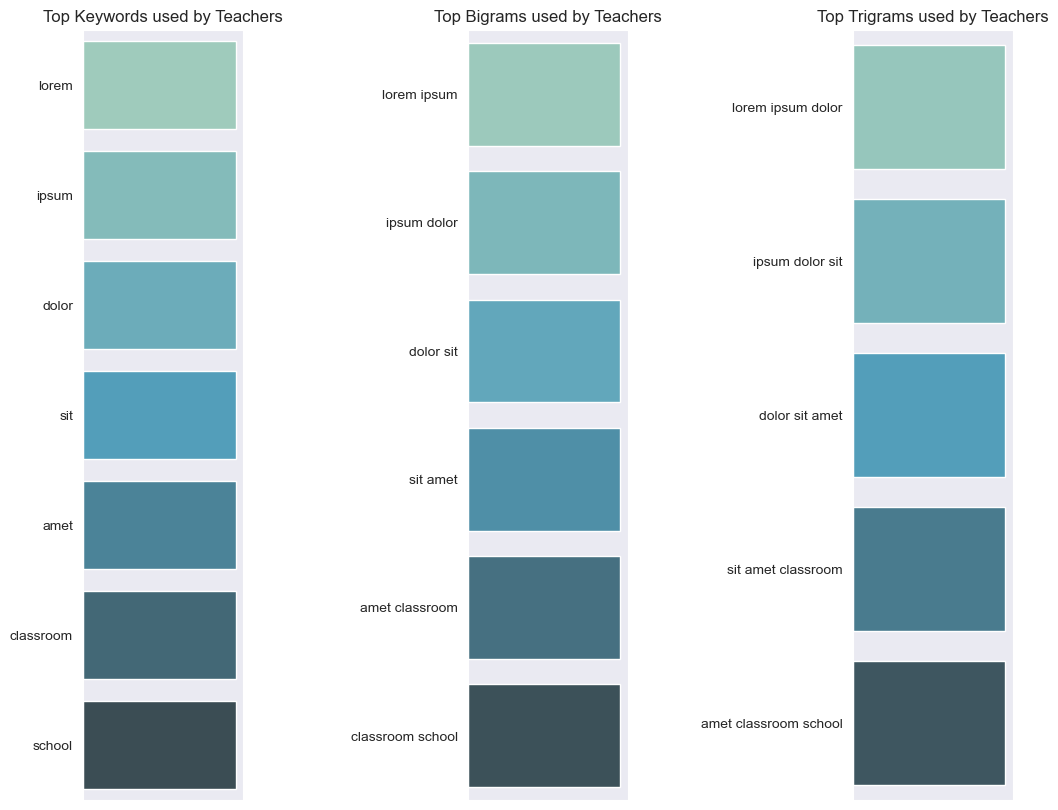

In [154]:
### Bag of Words 
from collections import Counter
def generate_ngrams(txt, N):
    grams = [txt[i:i+N] for i in range(len(txt)-N+1)]
    grams = [" ".join(b) for b in grams]
    return grams 

april18_df['unigrams'] = april18_df['Ensayo Limpio'].apply(lambda x : generate_ngrams(x.split(), 1))
april18_df['bigrams'] = april18_df['Ensayo Limpio'].apply(lambda x : generate_ngrams(x.split(), 2))
april18_df['trigrams'] = april18_df['Ensayo Limpio'].apply(lambda x : generate_ngrams(x.split(), 3))

all_unigrams = []
for each in april18_df['unigrams']:
    all_unigrams.extend(each)
t = Counter(all_unigrams).most_common(25)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df['bigrams']:
    all_bigrams.extend(each)
t1 = Counter(all_bigrams).most_common(25)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]


all_trigrams = []
for each in april18_df['trigrams']:
    all_trigrams.extend(each)
t2 = Counter(all_trigrams).most_common(25)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,10));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top Keywords used by Teachers");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top Bigrams used by Teachers");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top Trigrams used by Teachers");


> Las palabras clave más utilizadas en todos los ensayos, en todos los estados y en todos los tipos de escuelas son "escuela", "aprendizaje" y "aula", y "lectura". Mientras que los bigramas incluyen un enfoque principal en "asientos flexibles" y "idioma inglés". Un gran número de ensayos de maestros tratan sobre "Desayuno y almuerzo gratis", "aprender el idioma inglés" y "varios desafíos enfrentados".

## 8.2.2 Cómo varían las frases más usadas según el estado <a id='s8.2.2'></a>

**Nota:** Esta sección (análisis de frases más usadas por estado) no se pudo ejecutar porque los identificadores de escuela (`School ID`) entre los datasets de proyectos y escuelas no coinciden entre sí, por lo que no fue posible asociar los proyectos con su estado correspondiente.
ignores = ['every day', 'come school']
all_unigrams = []
for each in april18_df[april18_df['School State'] == 'California']['Trigramas']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'Georgia']['Trigramas']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Florida']['Trigramas']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - California");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - Georgia");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Florida");

all_unigrams = []
for each in april18_df[april18_df['School State'] == 'Iowa']['Trigramas']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'New York']['Trigramas']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Texas']['Trigramas']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - Iowa");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - New York");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Texas");

>* El enfoque principal de los ensayos en diferentes estados es básicamente el mismo, aunque se pueden observar algunas diferencias en estados como Texas, donde un gran número de ensayos trata sobre estudiantes afectados por el huracán Harvey. Los maestros han descrito sobre "varios desafíos que enfrentan" los estudiantes. "Opciones de asientos flexibles" es el enfoque principal de la mayoría de los ensayos.
>* En Iowa, los maestros han comentado sobre "estudiantes que provienen de diferentes orígenes" y "diferentes nacionalidades". En Nueva York, los ensayos también se centran en "profesores de educación especial", "escuelas en distritos pobres" y "bajos ingresos".
>* En Florida, los maestros mencionaron sobre "precios reducidos del desayuno y almuerzo".

## 8.2.3 "Mis estudiantes son ______ ______ ______": Lo que los maestros describen sobre sus estudiantes ¶ <a id='s8.2.3'></a>

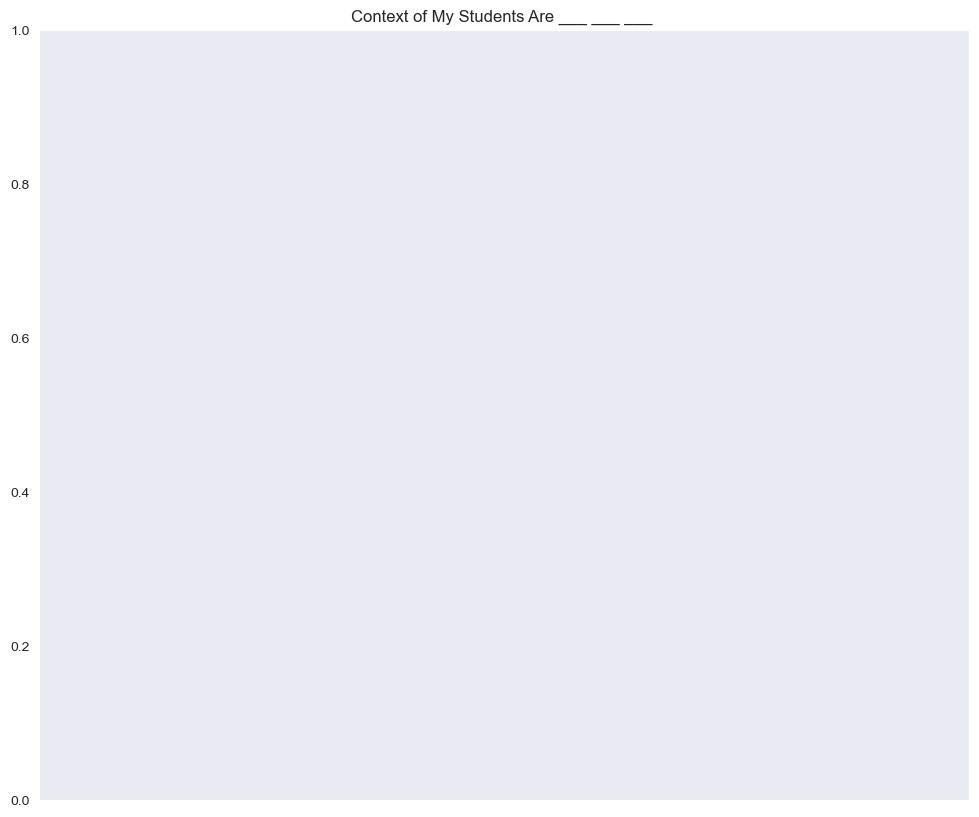

In [156]:
from textblob import TextBlob, Word
from wordcloud import WordCloud, STOPWORDS

mystudents = []
for x in april18_df['Project Essay']:
    if x.lower().startswith("my students are"):
        phrase = " ".join(x.replace('My students are', '').split(". ")[0].split("!")[0].strip().split()[:6])
        mystudents.append(phrase)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize = (12,10))
plt.title("Context of My Students Are ___ ___ ___ ");
bar = sns.barplot(y=x, x=y, palette="BuGn_r", edgecolor="white");
bar.set(xlabel='', xticks=[]);

> * Los maestros usaban muchos adjetivos para describir a sus estudiantes, por ejemplo: «increíble», «asombroso», «increíble», «creativo». Mientras que en algunos ensayos, los maestros describen a sus estudiantes como «muy especiales para ellos» y «notables».

##  8.2.4 Según lo descrito por los maestros, lo que los estudiantes necesitan ______ ______ ______  <a id='s8.2.4'></a>

**Nota:** Esta sección del análisis (frases sobre las necesidades de los estudiantes) no se pudo ejecutar porque la columna `Project Need Statement` no está disponible en la versión actual del dataset de Kaggle.
# Extraer frases relacionadas con las necesidades de los estudiantes
mystudents = []

for x in april18_df['clean_need']:
    if x.lower().strip().startswith("need"):
        phrase = " ".join(
            x.lower()
             .strip()
             .replace('need', '')
             .split(". ")[0]
             .split("!")[0]
             .strip()
             .split()[:3]
        )
        mystudents.append(phrase)

# Obtener las 25 frases más frecuentes
t3 = Counter(mystudents).most_common(25)

x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")

plt.figure(figsize=(12,10))

# Título de la gráfica en español
plt.title("Contenido de las necesidades de los estudiantes")

# Crear la gráfica de barras
bar = sns.barplot(
    y=x,
    x=y,
    palette="BuGn_r",
    edgecolor="white"
)

# Mantener el formato original de la gráfica
bar.set(
    xlabel='',
    xticks=[]
)

# Título de las palabras clave principales
axes[0].set_title("Palabras clave principales")

>* Aparte de la necesidad principal sugerida por los profesores, es decir, "Opciones de asientos flexibles", otras necesidades importantes son "Robot de programación" y "Suministros escolares básicos". En cuanto a los asientos flexibles, se enfocan en "Sillas oscilantes y asientos de balón de equilibrio", que son los más solicitados. Otras necesidades relacionadas con la tecnología incluyen "Tabletas Amazon Fire", "Auriculares" y "Kit Osmo Genius". 

## 8.2.5 Título del proyecto: Palabras más utilizadas <a id='s8.2.5'></a>

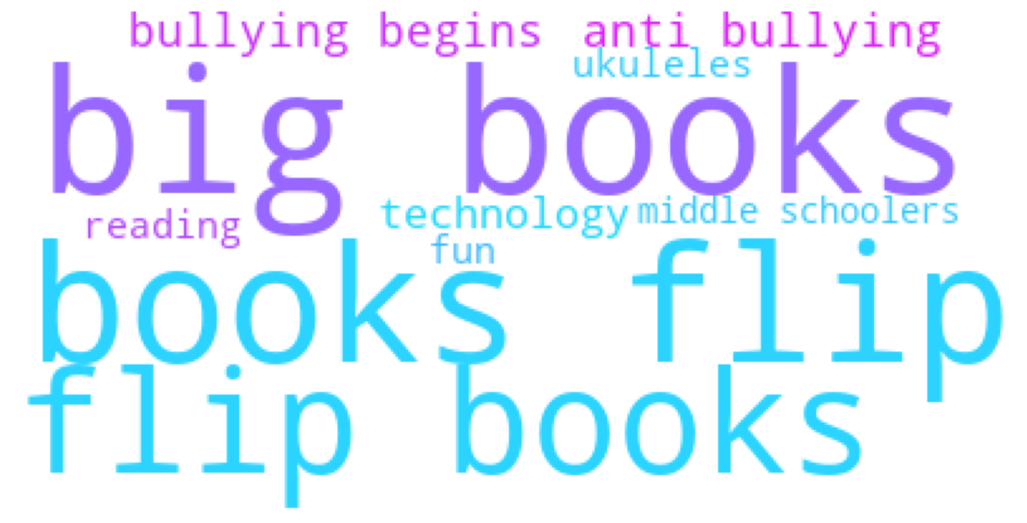

In [157]:
text = " ".join(april18_df['Project Title']).lower()
for w in ['need', 'student', 'classroom']: # remove some additional noise
    text = text.replace(w, " ")
wc = WordCloud(max_words=1200, stopwords=STOPWORDS, colormap='cool', background_color='White').generate(text)
plt.figure(figsize=(13,13))
plt.imshow(wc)
plt.axis('off')
plt.title('');

Temas como Asientos Flexibles, Chromebook, Lectura, Aprendizaje, Tecnología y libros son el enfoque principal de un gran número de maestros para sus estudiantes.

## 9. Entendiendo y Comparando las Características Clave de los Proyectos <a id='s9'></a>

## 9.1 Proyectos Expirados vs Proyectos Financiados <a id='s9.1'></a>

En esta sección, vamos a explorar y entender las características clave de los proyectos que fueron financiados con éxito y compararlos con los proyectos que expiraron. Me centraré en los proyectos del año pasado, es decir, 2017.

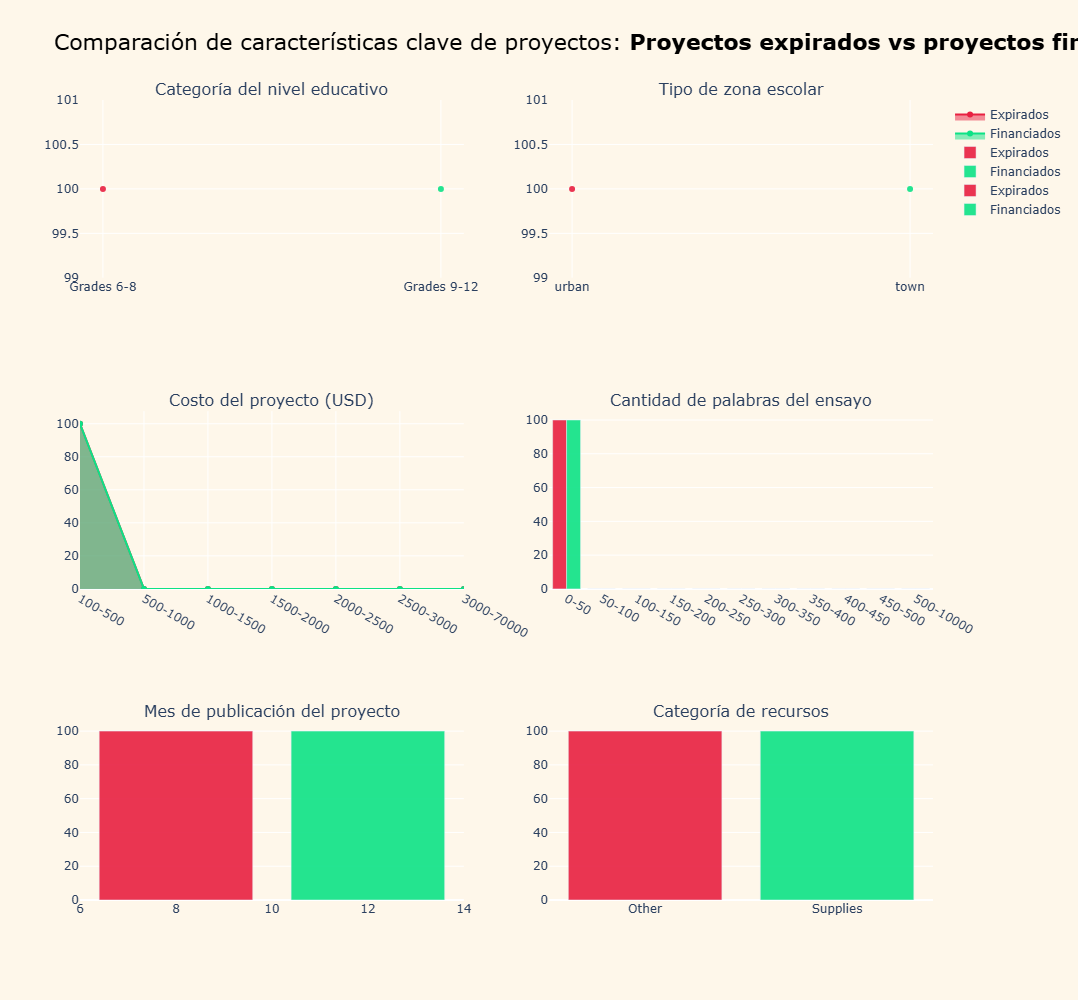

In [162]:
# Seleccionar proyectos expirados y completamente financiados del año 2015
expired = projects_df[projects_df['Año de Publicación'] == 2015][projects_df['Project Current Status'] == 'Expired']
funded = projects_df[projects_df['Año de Publicación'] == 2015][projects_df['Project Current Status'] == 'Fully Funded']

# Unir con la información de los docentes
expired = expired.merge(teachers_df, on="Teacher ID")
funded = funded.merge(teachers_df, on="Teacher ID")


# Función para generar las trazas de comparación
def get_trace(col, func, flag=None, leg=False):

    t1 = expired[col].value_counts()
    t2 = funded[col].value_counts()

    if flag == 'num':
        t1 = expired[expired['NumProjects'] <= 20][col].value_counts()
        t2 = funded[funded['NumProjects'] <= 20][col].value_counts()

    trace1 = func(
        x=t1.index,
        y=[float(a) * 100 / sum(t1.values) for a in t1.values],
        name='Expirados',
        marker=dict(color='#e82041'),
        showlegend=leg,
        opacity=0.9
    )

    trace2 = func(
        x=t2.index,
        y=[float(a) * 100 / sum(t2.values) for a in t2.values],
        name='Financiados',
        marker=dict(color='#0de286'),
        opacity=0.9,
        showlegend=leg
    )

    return trace1, trace2


tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Mes de Publicación', go.Bar, leg=True)


########################
# Comparación del número de palabras del ensayo

expired['ConteoPalabras'] = expired['Project Essay'].apply(lambda x: len(x.split()))
funded['ConteoPalabras'] = funded['Project Essay'].apply(lambda x: len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

expired['ConteoPalabras'] = pd.cut(expired['ConteoPalabras'], bins)

t1 = dict(expired['ConteoPalabras'].value_counts())

labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t1.values()) for a in list(t1.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

order = [
    '0-50', '50-100', '100-150', '150-200', '200-250',
    '250-300', '300-350', '350-400', '400-450',
    '450-500', '500-10000'
]

values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Expirados',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['ConteoPalabras'] = pd.cut(funded['ConteoPalabras'], bins)

t2 = dict(funded['ConteoPalabras'].value_counts())

labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t2.values()) for a in list(t2.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Financiados',
    marker=dict(color='#0de286'),
    opacity=0.9
)


############### costo ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

expired['CostoAgrupado'] = pd.cut(expired['Costo'], bins)

t1 = dict(expired['CostoAgrupado'].value_counts())

labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t1.values()) for a in list(t1.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

order = [
    '100-500', '500-1000', '1000-1500',
    '1500-2000', '2000-2500', '2500-3000',
    '3000-70000'
]

values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Expirados',
    fill='tozeroy',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['CostoAgrupado'] = pd.cut(funded['Costo'], bins)

t2 = dict(funded['CostoAgrupado'].value_counts())

labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t2.values()) for a in list(t2.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Financiados',
    fill='tozeroy',
    marker=dict(color='#0de286'),
    opacity=0.9
)


#############

titulos = [
    'Categoría del nivel educativo',
    'Tipo de zona escolar',
    'Costo del proyecto (USD)',
    'Cantidad de palabras del ensayo',
    'Mes de publicación del proyecto',
    'Categoría de recursos'
]

fig = tools.make_subplots(
    rows=3,
    cols=2,
    subplot_titles=titulos,
    print_grid=False,
    specs=[
        [{}, {}],
        [{}, {}],
        [{}, {}]
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)
fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)
fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)
fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)
fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)
fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)

fig['layout'].update(
    barmode='group',

    title=dict(
        text='Comparación de características clave de proyectos: '
             '<b>Proyectos expirados vs proyectos financiados</b><br>',
        font=dict(
            size=22,
            color='#000'
        )
    ),

    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)

iplot(fig);

Text(0.5, 1.0, 'Palabras más frecuentes - Proyectos financiados')

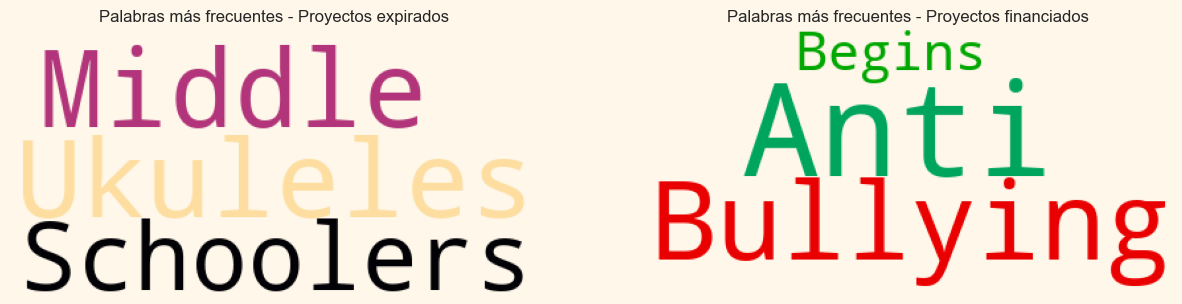

In [159]:
# Unir todos los títulos de proyectos financiados y expirados
texto_positivo_limpio = " ".join(funded['Project Title'])
texto_negativo_limpio = " ".join(expired['Project Title'])
# Función para generar tonos verdes
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(
        random.randint(85, 140),
        random.randint(60, 80)
    )
# Función para generar tonos rojos
def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(
        random.randint(0, 35),
        random.randint(60, 80)
    )
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=[15, 8],
    facecolor='#fef7ea'
)
# Nube de palabras para proyectos expirados
wordcloud1 = WordCloud(
    max_words=1200,
    colormap='magma',
    background_color='rgb(254, 247, 234)'
).generate(texto_negativo_limpio)
ax1.imshow(wordcloud1)
ax1.axis('off')
ax1.set_title(
    'Palabras más frecuentes - Proyectos expirados'
)
# Nube de palabras para proyectos financiados
wordcloud2 = WordCloud(
    max_words=1200,
    colormap='nipy_spectral',
    background_color='rgb(254, 247, 234)'
).generate(texto_positivo_limpio)
ax2.imshow(wordcloud2)
ax2.axis('off')
ax2.set_title(
    'Palabras más frecuentes - Proyectos financiados'
)

### La comparación muestra las siguientes conclusiones:

- Los proyectos pertenecientes a los niveles educativos de **Preescolar a 2.º grado (PreK-2)** presentan un mayor porcentaje de proyectos financiados exitosamente que de proyectos expirados. Mientras tanto, los demás niveles educativos muestran un mayor porcentaje de proyectos expirados que financiados. Esto podría deberse a que los donantes prefieren apoyar proyectos destinados a estudiantes de menor edad.

- Los proyectos financiados exitosamente presentan un mayor porcentaje de escuelas ubicadas en **zonas urbanas**, mientras que los proyectos expirados tienen una mayor proporción de escuelas ubicadas en **zonas rurales, suburbanas o pequeñas localidades**.

- Otra característica importante relacionada con los proyectos financiados es el **costo del proyecto**. Los proyectos cuyo costo total es inferior a **500 USD** tienen una probabilidad mucho mayor de ser financiados exitosamente, mientras que los proyectos cuyo costo supera los **500 USD** presentan una mayor probabilidad de no obtener financiamiento.

- Los ensayos de los proyectos son una parte esencial en los proyectos de DonorsChoose y la cantidad de palabras utilizadas parece ser un buen indicador del éxito del proyecto. Los proyectos financiados exitosamente suelen tener ensayos con una extensión superior a **250 palabras**, lo que sugiere que los docentes deben procurar redactar descripciones más completas y detalladas de sus proyectos.

- Un número significativo de proyectos publicados durante el **cuarto trimestre del año** (entre **octubre y diciembre**) fueron financiados exitosamente. Esto indica que una buena estrategia podría ser publicar los proyectos durante este periodo, ya que los donantes tienden a realizar más aportaciones durante los meses de **noviembre y diciembre**.

- Un hallazgo interesante entre los proyectos expirados es que una gran proporción de ellos presenta un elevado costo asociado a requerimientos técnicos, como **iPads, Chromebooks, suministros tecnológicos y equipos electrónicos**, categorías que muestran una mayor cantidad de proyectos no financiados.

- En los Estados Unidos existen algunos estados donde el porcentaje de proyectos financiados es mayor que el de proyectos expirados. Entre ellos se encuentran **Illinois, Massachusetts, Oklahoma y Florida**. Las campañas de promoción y marketing dirigidas específicamente a estos estados podrían ayudar a incrementar las donaciones provenientes de estas regiones.

- Una mayor proporción de proyectos financiados solicitó materiales relacionados con **lectura y aprendizaje flexible**, mientras que los proyectos expirados mostraron una mayor proporción de solicitudes relacionadas con **tecnología y equipos tecnológicos**.

## 9.2 Proyectos con duración de financiación baja vs alta <a id='s9.2'></a>

Ahora comparemos las características de los proyectos que se financiaron con éxito en un período más corto, es decir, menos de 1 día, frente a los proyectos que tardaron más de 2 meses en obtener financiación.

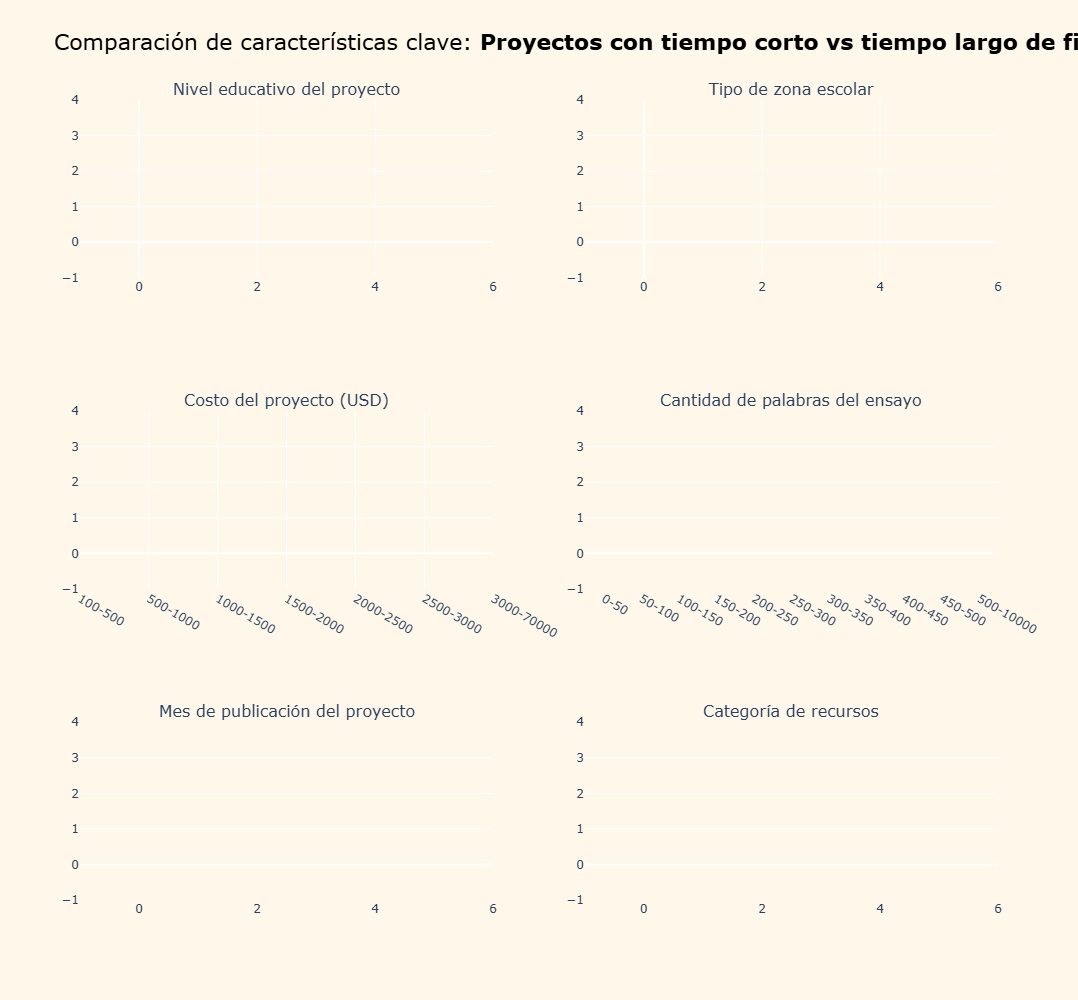

In [164]:
projects_df['time'] = projects_df['Funding Time'].apply(lambda x: str(x).split()[0])

tempdf = projects_df[projects_df['time'] != "NaT"]
tempdf['time'] = tempdf['time'].apply(int)

df1 = tempdf[tempdf['time'] <= 1]
df2 = tempdf[tempdf['time'] >= 60]

df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")


def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts()

    trace1 = func(
        x=t1.index,
        y=[float(a) * 100 / sum(t1.values) for a in t1.values],
        name='Tiempo corto de financiamiento',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )

    trace2 = func(
        x=t2.index,
        y=[float(a) * 100 / sum(t2.values) for a in t2.values],
        name='Tiempo largo de financiamiento',
        marker=dict(color='#e82041'),
        opacity=0.9,
        showlegend=leg
    )

    return trace1, trace2


tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
df1['wc'] = df1['Project Essay'].apply(lambda x: len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x: len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)
t1 = dict(df1['wc'].value_counts())
labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t1.values()) for a in list(t1.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

order = ['0-50', '50-100', '100-150', '150-200', '200-250',
         '250-300', '300-350', '350-400', '400-450',
         '450-500', '500-10000']

values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Tiempo corto de financiamiento',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)
t2 = dict(df2['wc'].value_counts())
labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t2.values()) for a in list(t2.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Tiempo largo de financiamiento',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


############### costo ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['Costo'], bins)
t1 = dict(df1['binnedcost'].value_counts())
labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t1.values()) for a in list(t1.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

order = ['100-500', '500-1000', '1000-1500',
         '1500-2000', '2000-2500',
         '2500-3000', '3000-70000']

values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Tiempo corto de financiamiento',
    fill='tozeroy',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['Costo'], bins)
t2 = dict(df2['binnedcost'].value_counts())
labels = [str(b).replace("]", "").replace("(", "").replace(", ", "-") for b in t1.keys()]
vals = [float(a) * 100 / sum(t2.values()) for a in list(t2.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Tiempo largo de financiamiento',
    fill='tozeroy',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


titles = [
    'Nivel educativo del proyecto',
    'Tipo de zona escolar',
    'Costo del proyecto (USD)',
    'Cantidad de palabras del ensayo',
    'Mes de publicación del proyecto',
    'Categoría de recursos'
]

fig = tools.make_subplots(
    rows=3,
    cols=2,
    subplot_titles=titles,
    print_grid=False,
    specs=[
        [{}, {}],
        [{}, {}],
        [{}, {}],
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)
fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)
fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)
fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)
fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)
fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)

fig['layout'].update(
    barmode='group',
    title=dict(
        text='Comparación de características clave: <b>Proyectos con tiempo corto vs tiempo largo de financiamiento</b><br>',
        font=dict(
            size=22,
            color='#000'
        )
    ),
    legend=dict(
        x=0.25,
        y=1.06,
        orientation="h"
    ),
    margin=dict(
        t=100,
        b=100
    ),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)

iplot(fig)

**Nota:** Esta nube de palabras no se pudo generar porque, debido al tamaño reducido del dataset, no hay suficientes proyectos con tiempos de financiamiento extremos (muy corto o muy largo) para generar contenido de texto significativo.
pos_text_cln = " ".join(df2['Project Title'])
neg_text_cln = " ".join(df1['Project Title'])
# Palabras que se eliminarán de las nubes de palabras
noise = ['Learning', 'Student', 'Classroom']
for n in noise:
    pos_text_cln = pos_text_cln.replace(n, " ")
    neg_text_cln = neg_text_cln.replace(n, " ")
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(
        random.randint(85, 140),
        random.randint(60, 80)
    )
def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(
        random.randint(0, 35),
        random.randint(60, 80)
    )
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=[17, 8],
    facecolor='#fef7ea'
)
# Proyectos con menor tiempo de financiamiento
wordcloud1 = WordCloud(
    max_words=1200,
    colormap='magma',
    background_color='rgb(254, 247, 234)'
).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off')
ax1.set_title('Palabras más frecuentes - Proyectos con menor tiempo de financiamiento')
# Proyectos con mayor tiempo de financiamiento
wordcloud2 = WordCloud(
    max_words=1200,
    colormap='nipy_spectral',
    background_color='rgb(254, 247, 234)'
).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off')
ax2.set_title('Palabras más frecuentes - Proyectos con mayor tiempo de financiamiento')

### La comparación muestra las siguientes conclusiones:

- Se puede observar que los proyectos que fueron financiados exitosamente en un día o menos pertenecen con mayor frecuencia a los niveles educativos de **6.º a 12.º grado**, mientras que un mayor porcentaje de proyectos que tardaron más tiempo en completar su financiamiento corresponden a niveles educativos inferiores.

- Las **zonas suburbanas** presentaron un mayor porcentaje de proyectos completados en períodos de tiempo más cortos en comparación con otros tipos de áreas escolares.

- Como era de esperarse, los proyectos con un **costo total menor**, especialmente aquellos con un presupuesto inferior a **500 USD**, tuvieron mayores probabilidades de ser financiados y completados rápidamente en comparación con proyectos que requerían montos más elevados. Esta tendencia también puede observarse en las gráficas.

- En los proyectos que lograron financiarse en menos de un día, los docentes utilizaron una **mayor cantidad de palabras** en sus ensayos, generalmente superando las **250 palabras**. En contraste, los proyectos cuyos ensayos tenían menos de **500 palabras** tendieron a requerir más tiempo para completar su financiamiento.

- Un mayor número de proyectos publicados durante los meses de **febrero, marzo, agosto y octubre** fueron financiados exitosamente en períodos más cortos, mientras que los mayores porcentajes de proyectos que tardaron más tiempo en financiarse se observaron principalmente durante los meses de **septiembre y diciembre**.

## 9.3 Proyectos con donante único vs múltiples donantes <a id='s9.3'></a>

Vamos a comparar las características de los proyectos en los que un solo donante donó frente a los que donaron más de diez donantes.

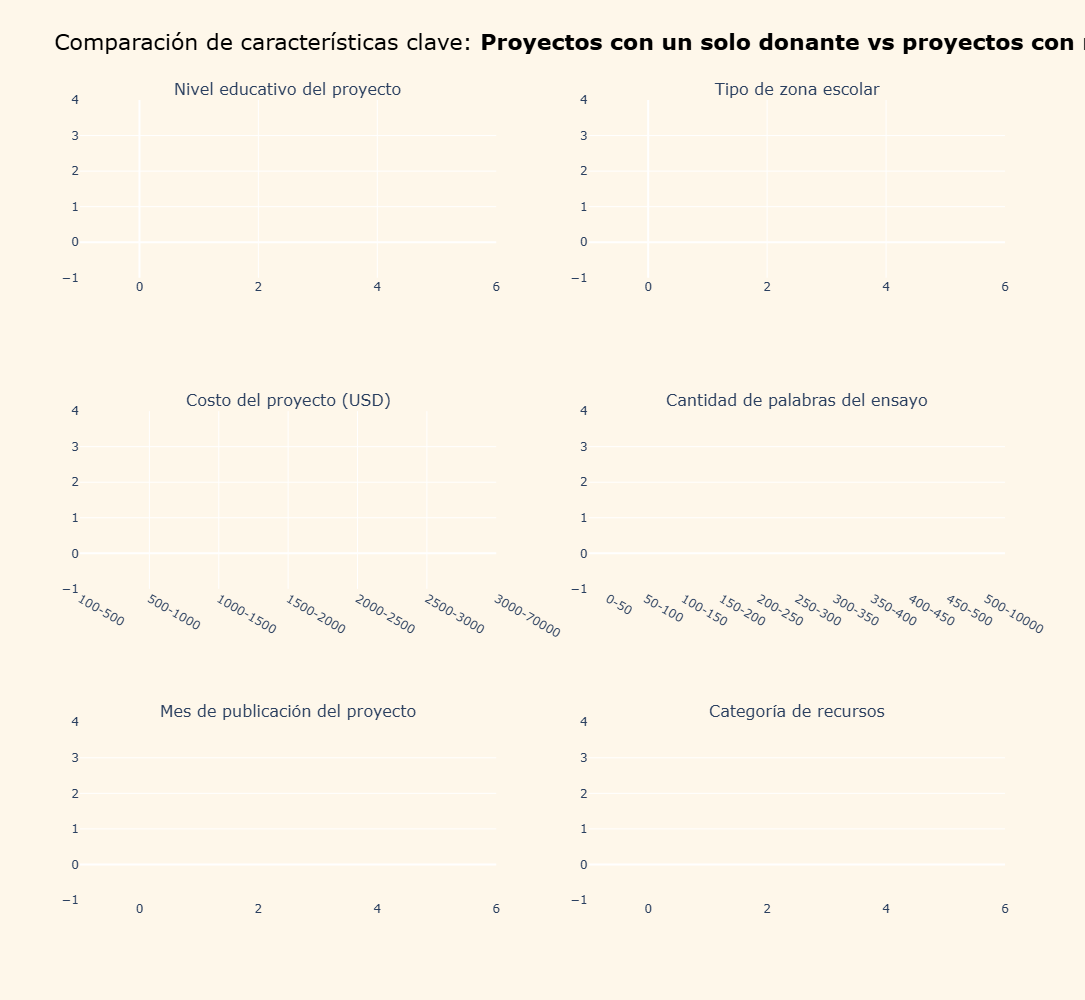

In [160]:
# Contar el número de donaciones por proyecto
num_donations = donations_df.groupby('Project ID').agg({
    'Donation ID': 'count'
}).reset_index().rename(columns={
    'Donation ID': 'NumDonations'
})

# Unir la información de proyectos con el número de donaciones
tempdf = projects_df.merge(num_donations, on="Project ID")

# Separar proyectos con un solo donante y con múltiples donantes (todos los años disponibles)
df1 = tempdf[tempdf['NumDonations'] == 1]
df2 = tempdf[tempdf['NumDonations'] > 10]

# Incorporar información de los docentes
df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")


# Función para generar las gráficas comparativas
def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts()

    trace1 = func(
        x=t1.index,
        y=[float(a) * 100 / sum(t1.values) for a in t1.values],
        name='Un solo donante',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )

    trace2 = func(
        x=t2.index,
        y=[float(a) * 100 / sum(t2.values) for a in t2.values],
        name='Múltiples donantes',
        marker=dict(color='#e82041'),
        opacity=0.9,
        showlegend=leg
    )

    return trace1, trace2


tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
# Cantidad de palabras en los ensayos
df1['wc'] = df1['Project Essay'].apply(lambda x: len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x: len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)
t1 = dict(df1['wc'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t1.keys()
]

vals = [float(a) * 100 / sum(t1.values()) for a in list(t1.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

order = [
    '0-50', '50-100', '100-150', '150-200', '200-250',
    '250-300', '300-350', '350-400', '400-450',
    '450-500', '500-10000'
]

values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Un solo donante',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)
t2 = dict(df2['wc'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t1.keys()
]

vals = [float(a) * 100 / sum(t2.values()) for a in list(t2.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Múltiples donantes',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


############### costo del proyecto ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['Costo'], bins)
t1 = dict(df1['binnedcost'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t1.keys()
]

vals = [float(a) * 100 / sum(t1.values()) for a in list(t1.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

order = [
    '100-500', '500-1000', '1000-1500',
    '1500-2000', '2000-2500',
    '2500-3000', '3000-70000'
]

values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Un solo donante',
    fill='tozeroy',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['Costo'], bins)
t2 = dict(df2['binnedcost'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t1.keys()
]

vals = [float(a) * 100 / sum(t2.values()) for a in list(t2.values())]

d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Múltiples donantes',
    fill='tozeroy',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


#############
# Títulos de las gráficas en español
titles = [
    'Nivel educativo del proyecto',
    'Tipo de zona escolar',
    'Costo del proyecto (USD)',
    'Cantidad de palabras del ensayo',
    'Mes de publicación del proyecto',
    'Categoría de recursos'
]

fig = tools.make_subplots(
    rows=3,
    cols=2,
    subplot_titles=titles,
    print_grid=False,
    specs=[
        [{}, {}],
        [{}, {}],
        [{}, {}],
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)

fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)

fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)

fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)

fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)

fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)

fig['layout'].update(
    barmode='group',

    title=dict(
        text='Comparación de características clave: <b>Proyectos con un solo donante vs proyectos con múltiples donantes</b><br>',
        font=dict(
            size=22,
            color='#000'
        )
    ),

    legend=dict(
        x=0.25,
        y=1.06,
        orientation="h"
    ),

    margin=dict(
        t=100,
        b=100
    ),

    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)

iplot(fig)

**Nota:** Esta nube de palabras no se pudo generar porque, debido al tamaño reducido del dataset, no hay suficientes proyectos que cumplan con los criterios de filtro (un solo donante / múltiples donantes) para generar contenido de texto significativo.
# Unir los títulos de los proyectos con múltiples donantes y con un solo donante
texto_positivo_limpio = " ".join(df2['Project Title'])
texto_negativo_limpio = " ".join(df1['Project Title'])
# Eliminar palabras muy comunes para mejorar la nube de palabras
ruido = ['Learning', 'Student', 'Classroom', 'Need']
for n in ruido:
    texto_positivo_limpio = texto_positivo_limpio.replace(n, " ")
    texto_negativo_limpio = texto_negativo_limpio.replace(n, " ")
# Función para generar colores verdes aleatorios
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(
        random.randint(85, 140),
        random.randint(60, 80)
    )
# Función para generar colores rojos aleatorios
def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(
        random.randint(0, 35),
        random.randint(60, 80)
    )
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=[17, 8],
    facecolor='#fef7ea'
)
# Nube de palabras para proyectos con un solo donante
wordcloud1 = WordCloud(
    max_words=1200,
    colormap='magma',
    background_color='rgb(254, 247, 234)'
).generate(texto_negativo_limpio)
ax1.imshow(wordcloud1)
ax1.axis('off')
ax1.set_title(
    'Palabras más frecuentes - Proyectos con un solo donante'
)
# Nube de palabras para proyectos con múltiples donantes
wordcloud2 = WordCloud(
    max_words=1200,
    colormap='nipy_spectral',
    background_color='rgb(254, 247, 234)'
).generate(texto_positivo_limpio)
ax2.imshow(wordcloud2)
ax2.axis('off')
ax2.set_title(
    'Palabras más frecuentes - Proyectos con múltiples donantes'
)

## Análisis de proyectos con uno y múltiples donantes

Con base en las gráficas y comparaciones anteriores, se pueden identificar varios patrones importantes relacionados con las características de los proyectos que recibieron un único donante y aquellos que lograron atraer múltiples donantes.

### Características de los proyectos con un solo donante

Los proyectos financiados por un único donante presentaron principalmente las siguientes características:

- Pertenecían con mayor frecuencia a los niveles educativos **Preescolar a 2° grado (PreK-2)**.
- Fueron publicados principalmente por escuelas ubicadas en **zonas urbanas**.
- Generalmente tenían un **costo menor del proyecto**.
- Los docentes redactaron ensayos relativamente cortos, normalmente con **menos de 250 palabras**.
- La mayoría de estos proyectos fueron publicados durante el mes de **septiembre**.
- Los recursos solicitados estuvieron relacionados principalmente con **libros y materiales de lectura**.

### Características de los proyectos con múltiples donantes

Los proyectos que lograron atraer a múltiples donantes compartieron las siguientes características:

- Pertenecían principalmente a los niveles educativos **3° a 5° grado**.
- Fueron publicados con mayor frecuencia por escuelas ubicadas en **zonas suburbanas y rurales**.
- Presentaban un **costo superior a los 500 dólares estadounidenses**.
- Los docentes escribieron ensayos más extensos y detallados.
- Los recursos solicitados estuvieron relacionados principalmente con **tecnología y suministros escolares**.

## Conclusión

El análisis sugiere que las características del proyecto influyen considerablemente en la cantidad de donantes que participan en su financiamiento.

Los proyectos pequeños, económicos y orientados a materiales básicos suelen ser cubiertos rápidamente por un único donante, mientras que los proyectos más costosos y enfocados en tecnología o equipamiento tienden a requerir la participación de múltiples donantes para alcanzar su objetivo financiero.

Asimismo, la ubicación de la escuela, el nivel educativo y la extensión del ensayo del proyecto parecen estar relacionados con el comportamiento de los donantes y el éxito de las campañas de financiamiento.